# Zero-Day Attack Detection — Behaviour-Aware IDS

**Dual-layer intrusion detection system using association rule mining on CIC-IDS (network) and ADFA-LD (host) datasets.**

| Step | Module | Description |
|------|--------|-------------|
| CIC 1 | `correlation.py` | Feature correlation analysis |
| CIC 2 | `sliding_window.py` | Sliding window preprocessing |
| CIC 3 | `discritize.py` | Feature discretisation (binning) |
| CIC 4 | `transactions.py` | Transaction generation (OHE) |
| CIC 5 | `rule_mining.py` | Normal behaviour learning |
| CIC 6 | `anomaly.py` | Anomaly detection |
| CIC 7 | `continuous_adaptation.py` | Continuous model adaptation |
| ADFA 1 | `adfa_preprocessing.py` | Syscall n-gram extraction |
| ADFA 2 | `adfa_rulemining.py` | Host-layer normal behaviour model |
| ADFA 3 | `adfa_anomaly.py` | Host-layer anomaly detection |
| CORR | `correlation.py` | Host–network score correlation |

---
## Global Configuration
Update the paths below to match your machine before running any step.

In [2]:
import os
BASE_DIR = os.getcwd()
CICIDS_DIR = os.path.join(BASE_DIR, "cicids_dataset")
ADFA_ROOT  = os.path.join(BASE_DIR, "ADFA-LD")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MONDAY_CSV = os.path.join(CICIDS_DIR, "monday.csv")
print("BASE_DIR   :", BASE_DIR)
print("CICIDS_DIR :", CICIDS_DIR)
print("ADFA_ROOT  :", ADFA_ROOT)
print("OUTPUT_DIR :", OUTPUT_DIR)

BASE_DIR   : C:\Users\Sai Deep\Desktop\aml4\aml4
CICIDS_DIR : C:\Users\Sai Deep\Desktop\aml4\aml4\cicids_dataset
ADFA_ROOT  : C:\Users\Sai Deep\Desktop\aml4\aml4\ADFA-LD
OUTPUT_DIR : C:\Users\Sai Deep\Desktop\aml4\aml4\outputs


---
## CIC-IDS 1: Feature Correlation Analysis
Identifies the most informative flow features from Monday benign data using Pearson correlation. Results are saved to `correlation_results.csv`.

In [6]:
"""
=============================================================
CORRELATION LAYER — Host-Network Anomaly Correlation
Behaviour-Aware IDS — CIC-IDS + ADFA-LD
=============================================================
We combine anomaly scores from both detection layers:
  CIC-IDS network layer : step6_anomaly_results.csv
  ADFA host layer       : adfa_step3_results.pkl
Output:
  correlation_results.csv  -- per-attack-type comparison
  correlation_summary.txt  -- report-ready summary
=============================================================
This file should be executed at last
"""
import os
import pickle
import numpy as np
import pandas as pd

CICIDS_CSV = os.path.join(OUTPUT_DIR, "step6_anomaly_results.csv")
ADFA_PKL   = os.path.join(OUTPUT_DIR, "adfa_step3_results.pkl")

CICIDS_THRESHOLD = 0.10
ADFA_THRESHOLD   = 0.45
CIC_WEIGHT       = 0.6
ADFA_WEIGHT      = 0.4

ADFA_COVERAGE_MAP = {
    'FTP-Patator'                           : 'Hydra_FTP',
    'FTP-Patator - Attempted'               : 'Hydra_FTP',
    'SSH-Patator'                           : 'Hydra_SSH',
    'SSH-Patator - Attempted'               : 'Hydra_SSH',
    'Web Attack - Brute Force'              : 'Web_Shell',
    'Web Attack - Brute Force - Attempted'  : 'Web_Shell',
    'Web Attack - XSS'                      : 'Web_Shell',
    'Web Attack - XSS - Attempted'          : 'Web_Shell',
    'Web Attack - SQL Injection'            : 'Web_Shell',
    'Web Attack - SQL Injection - Attempted': 'Web_Shell',
    'DoS GoldenEye'                         : 'Meterpreter',
    'DoS GoldenEye - Attempted'             : 'Meterpreter',
}

def compute_metrics(scores, true_binary, threshold):
    pred     = np.array(scores) >= threshold
    true_atk = np.array(true_binary) == 'ATTACK'
    TP = int(( pred &  true_atk).sum())
    TN = int((~pred & ~true_atk).sum())
    FP = int(( pred & ~true_atk).sum())
    FN = int((~pred &  true_atk).sum())
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr  = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    acc  = (TP + TN) / max(len(scores), 1)
    return dict(TP=TP, TN=TN, FP=FP, FN=FN,
                precision=prec, recall=rec, f1=f1, fpr=fpr, accuracy=acc)
def print_metrics(m, label=""):
    if label:
        print(f"  [{label}]")
    print(f"    TP={m['TP']:,}  FP={m['FP']:,}  FN={m['FN']:,}  TN={m['TN']:,}")
    print(f"    Recall    : {m['recall']:.4f}  ({m['recall']*100:.1f}%) <- most important for IDS")
    print(f"    Precision : {m['precision']:.4f}  ({m['precision']*100:.1f}%)")
    print(f"    F1        : {m['f1']:.4f}")
    print(f"    FPR       : {m['fpr']:.4f}  ({m['fpr']*100:.1f}%)")
print("  CORRELATION LAYER — Host-Network Anomaly Correlation")

# Load CIC-IDS results
print("\nLoading CIC-IDS network layer results ...")
cicids_df = pd.read_csv(CICIDS_CSV)
# Convert true labels to binary: 'ATTACK' or 'NORMAL'
cicids_df['true_binary'] = cicids_df['true_label'].apply(
    lambda x: 'NORMAL' if str(x).upper() == 'BENIGN' else 'ATTACK')
print(f"  Windows : {len(cicids_df):,}  |  "
      f"Attack: {(cicids_df['true_binary']=='ATTACK').sum():,}  |  "
      f"Benign: {(cicids_df['true_binary']=='NORMAL').sum():,}")
# Load ADFA results (pickled dict with results_df and per_category stats)
print(f"\nLoading ADFA host layer results ...")
with open(ADFA_PKL, 'rb') as f:
    adfa_data = pickle.load(f)
adfa_df    = adfa_data['results_df']
adfa_rates = {d['category']: d['det_rate'] for d in adfa_data['per_category']}
print(f"  Files  : {len(adfa_df):,}  |  "
      f"Attack: {(adfa_df['true_binary']=='ATTACK').sum()}  |  "
      f"Normal: {(adfa_df['true_binary']=='NORMAL').sum()}")

# Score distributions per layer (used for visualization/statistics)
b_cic = cicids_df[cicids_df['true_binary']=='NORMAL']['anomaly_score']
a_cic = cicids_df[cicids_df['true_binary']=='ATTACK']['anomaly_score']
b_adf = adfa_df[adfa_df['true_binary']=='NORMAL']['anomaly_score']
a_adf = adfa_df[adfa_df['true_binary']=='ATTACK']['anomaly_score']

print("SCORE DISTRIBUTION PER LAYER")
print(f"  CIC-IDS — Benign mean:{b_cic.mean():.4f}  Attack mean:{a_cic.mean():.4f}  Gap:{a_cic.mean()-b_cic.mean():+.4f}")
print(f"  ADFA    — Normal mean:{b_adf.mean():.4f}  Attack mean:{a_adf.mean():.4f}  Gap:{a_adf.mean()-b_adf.mean():+.4f}")

# Individual layer metrics
m_cic  = compute_metrics(cicids_df['anomaly_score'].values, cicids_df['true_binary'].values, CICIDS_THRESHOLD)
m_adfa = compute_metrics(adfa_df['anomaly_score'].values,   adfa_df['true_binary'].values,   ADFA_THRESHOLD)

print(f"\n{'─'*60}\nINDIVIDUAL LAYER EVALUATION METRICS\n{'─'*60}")
print_metrics(m_cic,  f"CIC-IDS network layer  threshold={CICIDS_THRESHOLD}")
print()
print_metrics(m_adfa, f"ADFA host layer  threshold={ADFA_THRESHOLD}")

# Per-attack-type coverage from CIC-IDS
cic_atk   = cicids_df[cicids_df['true_binary'] == 'ATTACK']
cic_rates = {}
for (atype, day), grp in cic_atk.groupby(['true_label', 'file']):
    det  = int((grp['anomaly_score'] >= CICIDS_THRESHOLD).sum())
    rate = det / len(grp)
    if atype not in cic_rates or rate > cic_rates[atype]:
        cic_rates[atype] = rate

# Three strategy comparison
print(f"\n{'─'*60}\nTHREE COMBINATION STRATEGIES COMPARED\n{'─'*60}")
print(f"  {'Attack Type':<40} {'CIC':>6} {'ADFA':>6} {'OR':>6} {'AND':>6} {'WGT':>6}")
print("  " + "─" * 72)

summary_rows = []
missed_cic = missed_or = missed_and = missed_wgt = 0

for atype, cic_rate in sorted(cic_rates.items(), key=lambda x: -x[1]):
    adfa_cat  = ADFA_COVERAGE_MAP.get(atype)
    adfa_rate = adfa_rates.get(adfa_cat, 0.0) if adfa_cat else 0.0
    or_rate   = max(cic_rate, adfa_rate)
    and_rate  = min(cic_rate, adfa_rate)
    wgt_rate  = CIC_WEIGHT * cic_rate + ADFA_WEIGHT * adfa_rate
    if cic_rate  < 0.20: missed_cic  += 1
    if or_rate   < 0.20: missed_or   += 1
    if and_rate  < 0.20: missed_and  += 1
    if wgt_rate  < 0.20: missed_wgt  += 1
    adfa_str = f"{adfa_rate:.3f}" if adfa_cat else "  N/A"
    flag     = ("OK" if or_rate >= 0.80 else ("~" if or_rate >= 0.40 else "XX"))
    print(f"  {flag} {atype:<40} {cic_rate:>6.3f} {adfa_str:>6} {or_rate:>6.3f} {and_rate:>6.3f} {wgt_rate:>6.3f}")
    summary_rows.append({
        'attack_type': atype, 'cic_rate': round(cic_rate, 4),
        'adfa_rate': round(adfa_rate, 4), 'or_rate': round(or_rate, 4),
        'and_rate': round(and_rate, 4),   'wgt_rate': round(wgt_rate, 4),
    })

print(f"\n  Fully missed attacks (<20% detection):")
print(f"    CIC-IDS alone       : {missed_cic}")
print(f"    OR  strategy (MAX)  : {missed_or}  <- chosen strategy")
print(f"    AND strategy (MIN)  : {missed_and}")
print(f"    Weighted avg        : {missed_wgt}")

# Save outputs
summary_df = pd.DataFrame(summary_rows)
csv_path   = os.path.join(OUTPUT_DIR, "correlation_results.csv")
summary_df.to_csv(csv_path, index=False)

txt_lines = [
    "CORRELATION LAYER — EVALUATION METRICS SUMMARY", "=" * 60,
    f"CIC-IDS threshold : {CICIDS_THRESHOLD}",
    f"ADFA threshold    : {ADFA_THRESHOLD}",
    f"Chosen strategy   : OR / MAX (flag if either layer detects)", "",
    "EVALUATION METRICS:",
    f"  CIC-IDS  Recall={m_cic['recall']:.4f}  Precision={m_cic['precision']:.4f}  F1={m_cic['f1']:.4f}  FPR={m_cic['fpr']:.4f}",
    f"  ADFA     Recall={m_adfa['recall']:.4f}  Precision={m_adfa['precision']:.4f}  F1={m_adfa['f1']:.4f}  FPR={m_adfa['fpr']:.4f}",
    "", "STRATEGY COMPARISON (fully missed attacks):",
    f"  CIC-IDS alone  : {missed_cic} missed",
    f"  OR  (MAX)      : {missed_or} missed  <- chosen",
    f"  AND (MIN)      : {missed_and} missed",
    f"  Weighted avg   : {missed_wgt} missed",
    "", "BLIND SPOTS COVERED BY ADFA:",
]
for row in summary_rows:
    if row['cic_rate'] < 0.20 and row['or_rate'] >= 0.20:
        txt_lines.append(f"  {row['attack_type']}: {row['cic_rate']*100:.1f}% -> {row['or_rate']*100:.1f}%")
txt_lines += ["", "LABEL USAGE: Labels used for evaluation only — not training.",
              "Training used benign Monday data exclusively (unsupervised)."]

txt_path = os.path.join(OUTPUT_DIR, "correlation_summary.txt")
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(txt_lines))

print(f"\nResults saved -> {csv_path}")
print(f"Summary saved -> {txt_path}")
print(f"\nCorrelation layer complete.")

  CORRELATION LAYER — Host-Network Anomaly Correlation

Loading CIC-IDS network layer results ...
  Windows : 141,971  |  Attack: 52,025  |  Benign: 89,946

Loading ADFA host layer results ...
  Files  : 946  |  Attack: 746  |  Normal: 200
SCORE DISTRIBUTION PER LAYER
  CIC-IDS — Benign mean:0.0975  Attack mean:0.1973  Gap:+0.0998
  ADFA    — Normal mean:0.6288  Attack mean:0.7434  Gap:+0.1146

────────────────────────────────────────────────────────────
INDIVIDUAL LAYER EVALUATION METRICS
────────────────────────────────────────────────────────────
  [CIC-IDS network layer  threshold=0.1]
    TP=39,283  FP=32,130  FN=12,742  TN=57,816
    Recall    : 0.7551  (75.5%) <- most important for IDS
    Precision : 0.5501  (55.0%)
    F1        : 0.6365
    FPR       : 0.3572  (35.7%)

  [ADFA host layer  threshold=0.45]
    TP=484  FP=96  FN=262  TN=104
    Recall    : 0.6488  (64.9%) <- most important for IDS
    Precision : 0.8345  (83.4%)
    F1        : 0.7300
    FPR       : 0.4800  (48

---
## CIC-IDS Step 2: Sliding Window Preprocessing
Groups benign Monday flows by IP pair and applies a sliding window (size=20, step=10) to preserve temporal behaviour context. Outputs `step2_windows.pkl` and `step2_features.pkl`.

In [3]:
"""
STEP 2 — Sliding Window Preprocessing
Behaviour-Aware IDS — CIC-IDS Dataset
"""
import pandas as pd
import numpy as np
import pickle
import os

#Here taking monday.csv file, as the file contains only normal data(benign data).
#through this we are going to train the model.
MONDAY_CSV = os.path.join(CICIDS_DIR, "monday.csv")
WINDOW_SIZE = 20
STEP_SIZE   = 10

RAW_FEATURES = [
    'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Packet Length Mean', 'Packet Length Std',
    'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Mean',
    'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
    'Dst Port', 'Fwd Packets/s',
    'RST Flag Count', 'FIN Flag Count', 'ACK Flag Count',
]

FEATURES_FOR_DOWNSTREAM = [
    'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Packet Length Mean', 'Packet Length Std',
    'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Mean',
    'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
    'Dst Port', 'Fwd Packets/s',
]
# It converts various timestamp formats to seconds, handling cases like "0.123", "00:00:01.234", or "2021-09-01 12:34:56".
# It tries to parse the timestamp in different formats and returns the total seconds. If parsing fails, it returns 0.0.
def to_sec(ts):
    try:
        ts = str(ts).strip()
        if "/" in ts and " " in ts:
            h, m, s = ts.split(" ")[1].split(":")
            return int(h) * 3600 + int(m) * 60 + float(s)
        if ":" in ts:
            p = ts.split(":")
            return float(p[0]) * 60 + float(p[1])
        return float(ts)
    except Exception:
        return 0.0
# It detects the source and destination IP columns in the DataFrame by checking for common column names. 
# It returns the names of the source and destination IP columns if found, or None if not found.
def detect_ip_cols(df):
    src = next((c for c in ['Source IP', 'Src IP', 'Src IP dec'] if c in df.columns), None)
    dst = next((c for c in ['Destination IP', 'Dst IP', 'Dst IP dec'] if c in df.columns), None)
    return src, dst
    
# It computes additional ratio features for a given window of data.
def compute_ratio_features(window_df):
    n = len(window_df)
    extra = {}
    for flag, col in [('RST_Ratio', 'RST Flag Count'), ('FIN_Ratio', 'FIN Flag Count'), ('ACK_Ratio', 'ACK Flag Count')]:
        vals = pd.to_numeric(window_df.get(col, pd.Series([0] * n)), errors='coerce').fillna(0)
        extra[flag] = float((vals > 0).sum() / n)
    if 'Dst Port' in window_df.columns:
        ports = window_df['Dst Port'].dropna()
        extra['Same_Dst_Port_Ratio'] = float(ports.value_counts().iloc[0] / len(ports)) if len(ports) > 0 else 0.0
    else:
        extra['Same_Dst_Port_Ratio'] = 0.0
    if 'Total Fwd Packet' in window_df.columns and 'Total Bwd packets' in window_df.columns:
        fwd = pd.to_numeric(window_df['Total Fwd Packet'], errors='coerce').fillna(0).sum()
        bwd = pd.to_numeric(window_df['Total Bwd packets'], errors='coerce').fillna(0).sum()
        extra['Bwd_Fwd_Ratio'] = float(bwd / max(fwd, 1))
    else:
        extra['Bwd_Fwd_Ratio'] = 1.0
    return extra
print("  STEP 2 — Sliding Window Preprocessing")
print("\nLoading Monday CSV ...")
#removes null and inf/-inf values, if there
df = pd.read_csv(MONDAY_CSV, low_memory=False)
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan)

if 'Label' not in df.columns:
    raise ValueError("'Label' column not found.")

benign = df[df['Label'].str.upper().str.contains('BENIGN', na=False)].copy()
print(f"  Total rows  : {len(df):,}")
print(f"  Benign rows : {len(benign):,}")

ts_col = 'Timestamp' if 'Timestamp' in benign.columns else None
benign['ts_seconds'] = (benign[ts_col].apply(to_sec) if ts_col else np.arange(len(benign), dtype=float))

src_col, dst_col = detect_ip_cols(benign)
if src_col and dst_col:
    benign['ip_pair'] = ["_".join(sorted([str(s), str(d)])) for s, d in zip(benign[src_col], benign[dst_col])]
else:
    benign['ip_pair'] = "port_" + benign['Dst Port'].astype(str)
    print("WARNING: IP columns not found — grouping by Dst Port")

print(f"IP pairs    : {benign['ip_pair'].nunique():,}")

keep   = list(dict.fromkeys([f for f in RAW_FEATURES if f in benign.columns] + ['ts_seconds', 'ip_pair', 'Label']))
benign = benign[keep].copy()

print(f"\nBuilding sliding windows (size={WINDOW_SIZE}, step={STEP_SIZE}) ...")
windows = []
for ip_pair, group in benign.groupby('ip_pair'):
    group = group.sort_values('ts_seconds').reset_index(drop=True)
    n     = len(group)
    for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        w     = group.iloc[start: start + WINDOW_SIZE].copy()
        extra = compute_ratio_features(w)
        for feat, val in extra.items():
            w[feat] = val
        w['window_id'] = f"{ip_pair}_w{start}"
        windows.append(w)

print(f"  Total windows : {len(windows):,}")
print(f"  Features used : {len(FEATURES_FOR_DOWNSTREAM)}")

w_path = os.path.join(OUTPUT_DIR, "step2_windows.pkl")
f_path = os.path.join(OUTPUT_DIR, "step2_features.pkl")
with open(w_path, 'wb') as f: pickle.dump(windows, f)
with open(f_path, 'wb') as f: pickle.dump(FEATURES_FOR_DOWNSTREAM, f)
print(f"\nSaved windows  -> {w_path}")
print(f"Saved features -> {f_path}")
print(f"\nStep 2 complete.")

  STEP 2 — Sliding Window Preprocessing

Loading Monday CSV ...
  Total rows  : 371,621
  Benign rows : 371,621
IP pairs    : 21,833

Building sliding windows (size=20, step=10) ...
  Total windows : 27,619
  Features used : 16

Saved windows  -> C:\Users\saish\OneDrive\Desktop\aml4\outputs\step2_windows.pkl
Saved features -> C:\Users\saish\OneDrive\Desktop\aml4\outputs\step2_features.pkl

Step 2 complete.


---
## CIC-IDS Step 3: Feature Discretisation (Binning)
Computes mean/max/std per window for each feature, then bins each statistic into LOW/MED/HIGH using the 33rd and 66th percentile boundaries learned from benign Monday training data. Outputs `step3_discrete_transactions.pkl` and `step3_bin_edges.pkl`.

In [4]:
"""
STEP 3 — Feature Discretisation (Binning)
Behaviour-Aware IDS — CIC-IDS Dataset
"""
import pandas as pd
import numpy as np
import pickle
import os

WINDOWS_PKL  = os.path.join(OUTPUT_DIR, "step2_windows.pkl")
FEATURES_PKL = os.path.join(OUTPUT_DIR, "step2_features.pkl")

print("  STEP 3 — Feature Discretisation")

print("\nLoading Step 2 outputs ...")
with open(WINDOWS_PKL,  'rb') as f: windows      = pickle.load(f)
with open(FEATURES_PKL, 'rb') as f: TOP_FEATURES = pickle.load(f)
print(f"  Windows  : {len(windows):,}")
print(f"  Features : {len(TOP_FEATURES)}")

# We compute mean, max, and std for each feature in each window.
# For each window, we create a row in 'stats_df' that contains the window_id and the computed statistics for each feature.
# We handle non-numeric values by force them to NaN and dropping them before calculations. If a feature has zero variance (std=0), we set std to 0.0 to avoid issues in later steps.
print("\nComputing mean / max / std per window ...")
rows = []
for window in windows:
    row = {'window_id': window['window_id'].iloc[0]}
    for feat in TOP_FEATURES:
        if feat not in window.columns:
            continue
        series = pd.to_numeric(window[feat], errors='coerce').dropna()
        if series.empty:
            continue
        row[f"{feat}__mean"] = series.mean()
        row[f"{feat}__max"]  = series.max()
        row[f"{feat}__std"]  = series.std() if len(series) > 1 else 0.0
    rows.append(row)

stats_df = pd.DataFrame(rows)
print(f"  Stats shape : {stats_df.shape}")
#Next, we compute bin edges for discretisation based on the 33rd and 66th percentiles of each feature's distribution across all windows.
#where p33 means the value below which 33% of the data falls, and p66 means the value below which 66% of the data falls.
#These percentiles help us define thresholds for categorising feature values into LOW, MEDIUM, and HIGH bins.
print("\nComputing bin edges (p33 / p66 from benign Monday data) ...")
stat_cols    = [c for c in stats_df.columns if c != 'window_id']
bin_edges    = {}
skipped_zero = []

for col in stat_cols:
    vals = pd.to_numeric(stats_df[col], errors='coerce').dropna()
    if len(vals) < 3:
        continue
    lo = float(np.percentile(vals, 33))
    hi = float(np.percentile(vals, 66))
    if lo == hi:
        skipped_zero.append(col)
        continue
    bin_edges[col] = [lo, hi]

print(f"  Bin edges saved : {len(bin_edges)}")
print(f"  Columns skipped : {len(skipped_zero)} (zero variance — expected)")

print("\n  Feature coverage check:")
for feat in TOP_FEATURES:
    ok = f"{feat}__mean" in bin_edges
    print(f"    {feat}: {'OK' if ok else 'SKIPPED (zero variance)'}")

print("\nDiscretising into LOW / MED / HIGH ...")
discrete_df              = pd.DataFrame()
discrete_df['window_id'] = stats_df['window_id']

for col in stat_cols:
    if col not in bin_edges:
        continue
    lo, hi = bin_edges[col]
    discrete_df[col] = stats_df[col].apply(
        lambda v, lo=lo, hi=hi, col=col: (
            None          if pd.isna(v) else
            f"{col}=LOW"  if v <= lo    else
            f"{col}=MED"  if v <= hi    else
            f"{col}=HIGH"
        )
    )

print(f"  Discrete shape : {discrete_df.shape}")

feat_cols = [c for c in discrete_df.columns if c != 'window_id']
flat      = discrete_df[feat_cols].values.flatten()
valid     = [v for v in flat if v is not None and not (isinstance(v, float) and np.isnan(v))]
dist      = pd.Series(valid).str.extract(r'=(LOW|MED|HIGH)')[0].value_counts()
print(f"\n  Label distribution (target ~33% each):")
for lbl, cnt in dist.items():
    print(f"    {lbl:5s}: {cnt:,}  ({cnt/len(valid)*100:.1f}%)")

d_path = os.path.join(OUTPUT_DIR, "step3_discrete_transactions.pkl")
b_path = os.path.join(OUTPUT_DIR, "step3_bin_edges.pkl")
with open(d_path, 'wb') as f: pickle.dump(discrete_df, f)
with open(b_path, 'wb') as f: pickle.dump(bin_edges, f)
print(f"\nSaved transactions -> {d_path}")
print(f"Saved bin edges    -> {b_path}")
print(f"\nStep 3 complete.")

  STEP 3 — Feature Discretisation

Loading Step 2 outputs ...
  Windows  : 27,619
  Features : 16

Computing mean / max / std per window ...
  Stats shape : (27619, 49)

Computing bin edges (p33 / p66 from benign Monday data) ...
  Bin edges saved : 45
  Columns skipped : 3 (zero variance — expected)

  Feature coverage check:
    Flow Duration: OK
    Total Fwd Packet: OK
    Total Bwd packets: OK
    Flow Bytes/s: OK
    Flow Packets/s: OK
    Flow IAT Mean: OK
    Flow IAT Std: OK
    Packet Length Mean: OK
    Packet Length Std: OK
    Fwd Packet Length Mean: OK
    Fwd Packet Length Std: OK
    Bwd Packet Length Mean: OK
    Total Length of Fwd Packet: OK
    Total Length of Bwd Packet: OK
    Dst Port: SKIPPED (zero variance)
    Fwd Packets/s: OK

Discretising into LOW / MED / HIGH ...
  Discrete shape : (27619, 46)

  Label distribution (target ~33% each):
    LOW  : 446,998  (36.0%)
    HIGH : 416,793  (33.5%)
    MED  : 379,064  (30.5%)

Saved transactions -> C:\Users\saish\O

---
## CIC-IDS Step 4: Transaction Generation
Converts discretised window labels into a boolean OHE matrix for FP-Growth. Each row = one window; each column = one item (e.g. `FlowDuration__mean=HIGH`). Outputs `step4_ohe_dataframe.pkl`.

In [5]:
"""
STEP 4 — Transaction Generation (One-Hot Encoding)
Behaviour-Aware IDS — CIC-IDS Dataset
"""
import pandas as pd
import numpy as np
import pickle
import os
DISCRETE_PKL = os.path.join(OUTPUT_DIR, "step3_discrete_transactions.pkl")
print("  STEP 4 — Transaction Generation (One-Hot Encoding)")
# We load the discrete transactions from Step 3, which are in a DataFrame where each row corresponds to a window and each column contains a categorical value like "feature=LOW", "feature=MED", or "feature=HIGH".
print("\nLoading Step 3 discrete transactions ...")
with open(DISCRETE_PKL, 'rb') as f:
    discrete_df = pickle.load(f)
print(f"  Shape : {discrete_df.shape}")

print("\nBuilding boolean OHE matrix ...")
feat_cols = [c for c in discrete_df.columns if c != 'window_id']

melted = (
    discrete_df[feat_cols]
    .reset_index()
    .melt(id_vars='index', value_vars=feat_cols, value_name='item')
    .dropna(subset=['item'])
    [['index', 'item']]
)

ohe_df = pd.crosstab(melted['index'], melted['item']).astype(bool)
ohe_df = ohe_df.reindex(range(len(discrete_df)), fill_value=False)

mem_mb       = ohe_df.memory_usage(deep=True).sum() / 1024 ** 2
true_per_row = ohe_df.sum(axis=1)

print(f"  OHE shape    : {ohe_df.shape}")
print(f"  Memory       : {mem_mb:.1f} MB")
print(f"  Items/row    : mean={true_per_row.mean():.1f}  min={true_per_row.min()}  max={true_per_row.max()}")

out_path = os.path.join(OUTPUT_DIR, "step4_ohe_dataframe.pkl")
with open(out_path, 'wb') as f:
    pickle.dump(ohe_df, f)
print(f"\nSaved -> {out_path}")
print(f"\nStep 4 complete.")

  STEP 4 — Transaction Generation (One-Hot Encoding)

Loading Step 3 discrete transactions ...
  Shape : (27619, 46)

Building boolean OHE matrix ...
  OHE shape    : (27619, 135)
  Memory       : 3.6 MB
  Items/row    : mean=45.0  min=45  max=45

Saved -> C:\Users\saish\OneDrive\Desktop\aml4\outputs\step4_ohe_dataframe.pkl

Step 4 complete.


---
## CIC-IDS Step 5: Normal Behaviour Learning (Association Rule Mining)
Mines association rules from benign Monday transactions using a **7-stage pruning pipeline** that reduces thousands of raw rules down to 50 high-quality, stable normal behaviour patterns. Outputs `step5_normal_behaviour_model.pkl`.

In [7]:
"""
STEP 5 — Normal Behaviour Learning (Association Rule Mining)
Behaviour-Aware IDS — CIC-IDS Dataset
7-Stage pipeline:
  Stage 1  FP-Growth — support=0.05, conf=0.82, lift>=1.8
  Stage 2  Closed itemset filter
  Stage 3  Dominance filter (<5% confidence gain removed)
  Stage 4  Symmetric deduplication
  Stage 5  Pattern stability analysis
  Stage 6  Feature-level clustering
  Stage 7  Composite scoring — top 50 rules kept
"""

import pandas as pd
import numpy as np
import pickle
import os
import time
from itertools import combinations
from mlxtend.frequent_patterns import fpgrowth, association_rules

OHE_PKL       = os.path.join(OUTPUT_DIR, "step4_ohe_dataframe.pkl")
BIN_EDGES_PKL = os.path.join(OUTPUT_DIR, "step3_bin_edges.pkl")
FEATURES_PKL  = os.path.join(OUTPUT_DIR, "step2_features.pkl")
OUTPUT_MODEL  = os.path.join(OUTPUT_DIR, "step5_normal_behaviour_model.pkl")

MIN_SUPPORT         = 0.05
MIN_CONFIDENCE      = 0.82
MIN_LIFT            = 1.8
MAX_LEN             = 2
CONF_GAIN_THRESHOLD = 0.05
N_FOLDS             = 3
MIN_STABILITY_FOLDS = 2
TOP_N_RULES         = 50
W_LIFT = 0.4; W_CONFIDENCE = 0.3; W_SUPPORT = 0.2; W_STABILITY = 0.1
STATS = ['mean', 'max', 'std']

def item_to_feature(item):
    return item.split('__')[0]
#Removes rules antecedent is a subset of a longer rule with equal or higher support.
#This shorter rules are redundant, they tell us nothing extra that the longer rule doesn't already capture
def stage2_closed_filter(rules_df, frequent_itemsets):
    print("  Stage 2: Closed itemset filter ...")
    t0      = time.time()
    sup_map = {frozenset(r['itemsets']): r['support'] for _, r in frequent_itemsets.iterrows()}
    all_sets = list(sup_map.keys())
    closed  = {s for s in all_sets if not any(s < o and sup_map.get(o, -1) >= sup_map[s] - 1e-9 for o in all_sets)}
    before  = len(rules_df)
    rules_df = rules_df[rules_df['antecedents'].apply(lambda a: frozenset(a) in closed)].copy()
    print(f"    {len(rules_df):,}/{before:,}  (-{before-len(rules_df):,})  [{time.time()-t0:.1f}s]")
    return rules_df
#This stage removes rules that barely improve.
#If adding more conditions only makes 1 or 2 percent better, so not worth it. Keep the simple rule.
def stage3_dominance_filter(rules_df, conf_gain=0.05):
    print(f"  Stage 3: Dominance filter ...")
    t0 = time.time()
    rules_df = rules_df.copy()
    rules_df['ant_len'] = rules_df['antecedents'].apply(len)
    rules_df = rules_df.sort_values(['ant_len', 'confidence'], ascending=[True, False]).reset_index(drop=True)
    registry, kept = {}, []
    for idx, row in rules_df.iterrows():
        ant, con, conf = frozenset(row['antecedents']), frozenset(row['consequents']), row['confidence']
        dominated = False
        for sz in range(1, len(ant)):
            for sub in combinations(sorted(ant), sz):
                key = (frozenset(sub), con)
                if key in registry and conf < registry[key] + conf_gain:
                    dominated = True; break
            if dominated: break
        if not dominated:
            kept.append(idx); registry[(ant, con)] = conf
    before = len(rules_df)
    rules_df = rules_df.loc[kept].reset_index(drop=True)
    print(f"    {len(rules_df):,}/{before:,}  (-{before-len(rules_df):,})  [{time.time()-t0:.1f}s]")
    return rules_df
#Here removing mirror rules,
#Where two rules saying the same thing in opposite directions, keep the stronger one and remove the weak once.
def stage4_symmetric_dedup(rules_df):
    print("  Stage 4: Symmetric deduplication ...")
    t0 = time.time()
    rules_df = rules_df.copy()
    rules_df['_score'] = rules_df['lift'] * rules_df['confidence']
    seen, kept_idx = set(), []
    for idx, row in rules_df.iterrows():
        ant, con = frozenset(row['antecedents']), frozenset(row['consequents'])
        fwd, rev = (ant, con), (con, ant)
        if rev in seen:
            for k in kept_idx:
                kr = rules_df.loc[k]
                if (frozenset(kr['antecedents']), frozenset(kr['consequents'])) == rev:
                    if row['_score'] > kr['_score']:
                        kept_idx.remove(k); kept_idx.append(idx)
                        seen.discard(rev); seen.add(fwd)
                    break
        elif fwd not in seen:
            kept_idx.append(idx); seen.add(fwd)
    before = len(rules_df)
    rules_df = rules_df.loc[kept_idx].reset_index(drop=True)
    print(f"    {len(rules_df):,}/{before:,}  (-{before-len(rules_df):,})  [{time.time()-t0:.1f}s]")
    return rules_df.drop(columns=['_score'], errors='ignore')
#In this stage we split training into 3 periods , every rule must work in at least 2 of 3, the once which are not satisfing are removed.
#Rules that only worked sometimes were removed.
def stage5_stability_analysis(rules_df, ohe_df, n_folds=3, min_folds=2):
    print(f"  Stage 5: Pattern stability ({n_folds} folds, min={min_folds}) ...")
    t0 = time.time()
    n = len(ohe_df); fold_size = n // n_folds
    folds = [ohe_df.iloc[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    fold_freqs = [f.mean() for f in folds]
    stab_scores = []
    for _, row in rules_df.iterrows():
        ant_items = list(row['antecedents'])
        qualified = sum(1 for ff in fold_freqs if all(ff.get(item, 0) >= MIN_SUPPORT for item in ant_items))
        stab_scores.append(qualified / n_folds)
    rules_df = rules_df.copy()
    rules_df['stability_score'] = stab_scores
    before = len(rules_df)
    rules_df = rules_df[rules_df['stability_score'] >= (min_folds / n_folds)].copy()
    fully_stable = (rules_df['stability_score'] >= 0.99).sum()
    print(f"    {len(rules_df):,}/{before:,}  (-{before-len(rules_df):,})  [{time.time()-t0:.1f}s]")
    print(f"    Fully stable (3/3 folds): {fully_stable}/{len(rules_df)}")
    return rules_df
#Many rules still say the same relationship differently, so we group them and kept only the best one per group.
def stage6_feature_clustering(rules_df):
    print("  Stage 6: Feature-level clustering ...")
    t0 = time.time()
    rules_df = rules_df.copy()
    def fkey(row):
        af = tuple(sorted(set(item_to_feature(i) for i in row['antecedents'])))
        cf = tuple(sorted(set(item_to_feature(i) for i in row['consequents'])))
        return (af, cf)
    rules_df['_fkey']  = rules_df.apply(fkey, axis=1)
    rules_df['_score'] = rules_df['lift'] * rules_df['confidence']
    kept_idx           = rules_df.groupby('_fkey')['_score'].idxmax().values
    before = len(rules_df)
    rules_df = rules_df.loc[kept_idx].reset_index(drop=True)
    print(f"    {len(rules_df):,}/{before:,}  (-{before-len(rules_df):,})  [{time.time()-t0:.1f}s]")
    return rules_df.drop(columns=['_fkey', '_score'], errors='ignore')
#Here we ranked every surving rule by quality, strength, reliability, frequency and consistency combined.
#0.4×lift + 0.3×conf + 0.2×support + 0.1×stability
def stage7_composite_selection(rules_df, n):
    print(f"  Stage 7: Composite scoring + top-{n} selection ...")
    rules_df = rules_df.copy()
    max_lift = rules_df['lift'].max() or 1.0
    max_sup  = rules_df['support'].max() or 1.0
    rules_df['composite_score'] = (
        W_LIFT       * (rules_df['lift']    / max_lift) +
        W_CONFIDENCE *  rules_df['confidence']          +
        W_SUPPORT    * (rules_df['support'] / max_sup)  +
        W_STABILITY  *  rules_df['stability_score']
    )
    rules_df = rules_df.nlargest(n, 'composite_score').reset_index(drop=True)
    print(f"    Final rules: {len(rules_df)}")
    return rules_df
print("  STEP 5 — Normal Behaviour Learning")
print("\n Loading inputs ...")
with open(OHE_PKL,       'rb') as f: ohe_df       = pickle.load(f)
with open(BIN_EDGES_PKL, 'rb') as f: bin_edges    = pickle.load(f)
with open(FEATURES_PKL,  'rb') as f: top_features = pickle.load(f)
print(f"  Transactions : {ohe_df.shape[0]:,} x {ohe_df.shape[1]} items")

ohe_features = set(col.split('__')[0] for col in ohe_df.columns if '__' in col)
top_features = [f for f in top_features if f in ohe_features]
print(f"  Features used: {len(top_features)}")

item_freq   = ohe_df.mean().sort_values(ascending=False)
eff_support = MIN_SUPPORT if (item_freq >= MIN_SUPPORT).sum() >= 15 else 0.03

print(f"\nStage 1: FP-Growth  support={eff_support}  conf={MIN_CONFIDENCE}  lift>={MIN_LIFT}")
t0 = time.time()
frequent_itemsets = fpgrowth(ohe_df, min_support=eff_support, use_colnames=True, max_len=MAX_LEN)
print(f"  Frequent itemsets : {len(frequent_itemsets):,}  ({time.time()-t0:.1f}s)")

raw_rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules     = raw_rules[raw_rules['lift'] >= MIN_LIFT].copy()
total_raw = len(rules)
print(f"  Raw rules : {total_raw:,}")

print(f"\nStages 2-4: Structural pruning ...")
if len(rules) > 100:
    rules = stage2_closed_filter(rules, frequent_itemsets)
    if rules.empty: rules = raw_rules[raw_rules['lift'] >= MIN_LIFT].copy()
if not rules.empty: rules = stage3_dominance_filter(rules, CONF_GAIN_THRESHOLD)
if not rules.empty: rules = stage4_symmetric_dedup(rules)

print(f"\nStage 5: Pattern stability ...")
if not rules.empty: rules = stage5_stability_analysis(rules, ohe_df, N_FOLDS, MIN_STABILITY_FOLDS)
if rules.empty:
    rules = stage5_stability_analysis(raw_rules[raw_rules['lift'] >= MIN_LIFT].copy(), ohe_df, N_FOLDS, 1)

print(f"\nStage 6: Feature-level clustering ...")
if not rules.empty: rules = stage6_feature_clustering(rules)

print(f"\nStage 7: Composite scoring ...")
if not rules.empty: rules = stage7_composite_selection(rules, TOP_N_RULES)

print(f"\n  ALL {len(rules)} RULES:")
print(f"  {'#':<4} {'Antecedent':<36} {'Consequent':<20} {'Sup':>5} {'Conf':>6} {'Lift':>6} {'Stab':>5} {'Score':>7}")
print("  " + "─" * 90)
for i, (_, row) in enumerate(rules.iterrows()):
    ant   = ", ".join(sorted(row['antecedents']))
    con   = ", ".join(sorted(row['consequents']))
    stab  = row.get('stability_score', 1.0)
    score = row.get('composite_score', 0.0)
    print(f"  {i+1:<4} {ant[:35]:<36} {con[:19]:<20} {row['support']:>5.3f} {row['confidence']:>6.3f} {row['lift']:>6.3f} {stab:>5.2f} {score:>7.4f}")

rule_lookup = []
for _, row in rules.iterrows():
    rule_lookup.append({
        'antecedents'    : set(row['antecedents']),
        'consequents'    : set(row['consequents']),
        'confidence'     : float(row['confidence']),
        'lift'           : float(row['lift']),
        'support'        : float(row['support']),
        'stability_score': float(row.get('stability_score', 1.0)),
        'composite_score': float(row.get('composite_score', 0.0)),
        'weight'         : float(row['lift'] * row['confidence']),
    })

model = {
    'rule_lookup' : rule_lookup,
    'bin_edges'   : bin_edges,
    'top_features': top_features,
    'stats'       : STATS,
    'params': {'min_support': eff_support, 'min_confidence': MIN_CONFIDENCE,
               'min_lift': MIN_LIFT, 'max_len': MAX_LEN, 'top_n_rules': TOP_N_RULES},
}
with open(OUTPUT_MODEL, 'wb') as f:
    pickle.dump(model, f)
print(f"\nModel saved -> {OUTPUT_MODEL}")
print(f"\nStep 5 complete.")

  STEP 5 — Normal Behaviour Learning

 Loading inputs ...
  Transactions : 27,619 x 135 items
  Features used: 15

Stage 1: FP-Growth  support=0.05  conf=0.82  lift>=1.8
  Frequent itemsets : 7,172  (273.9s)
  Raw rules : 441

Stages 2-4: Structural pruning ...
  Stage 2: Closed itemset filter ...
    431/441  (-10)  [1.6s]
  Stage 3: Dominance filter ...
    431/431  (-0)  [0.0s]
  Stage 4: Symmetric deduplication ...
    255/431  (-176)  [0.4s]

Stage 5: Pattern stability ...
  Stage 5: Pattern stability (3 folds, min=2) ...
    255/255  (-0)  [0.0s]
    Fully stable (3/3 folds): 223/255

Stage 6: Feature-level clustering ...
  Stage 6: Feature-level clustering ...
    50/255  (-205)  [0.0s]

Stage 7: Composite scoring ...
  Stage 7: Composite scoring + top-50 selection ...
    Final rules: 50

  ALL 50 RULES:
  #    Antecedent                           Consequent             Sup   Conf   Lift  Stab   Score
  ───────────────────────────────────────────────────────────────────────────

---
## CIC-IDS Step 6: Anomaly Detection (Weighted Violation Scoring)
Scores each test window (Tue–Fri) by how much it violates the normal behaviour rules from Step 5. Score 0.0 = all rules satisfied; score 1.0 = every applicable rule violated. Outputs `step6_anomaly_results.csv`.

In [7]:
"""
STEP 6 — Anomaly Detection (Weighted Violation Scoring)
Behaviour-Aware IDS: CIC-IDS Dataset
weight_i      = lift_i x confidence_i   (rule strength)
anomaly_score = sum(weight : violated) / sum(weight : applicable)
"""

import pandas as pd
import numpy as np
import pickle
import os
import time
from collections import defaultdict

MODEL_PATH = os.path.join(OUTPUT_DIR, "step5_normal_behaviour_model.pkl")

ATTACK_FILES = [
    os.path.join(CICIDS_DIR, "tuesday.csv"),
    os.path.join(CICIDS_DIR, "wednesday.csv"),
    os.path.join(CICIDS_DIR, "thursday.csv"),
    os.path.join(CICIDS_DIR, "friday.csv"),
]

WINDOW_SIZE        = 20
STEP_SIZE          = 10
STATS              = ['mean', 'max', 'std']
RECOMMENDED_THRESH = 0.10
# Converts a timestamp string into seconds for proper ordering
# Supports "HH:MM:SS", "MM:SS", or "YYYY/MM/DD HH:MM:SS" formats
def to_sec(ts):
    try:
        ts = str(ts).strip()
        if "/" in ts and " " in ts:
            h, m, s = ts.split(" ")[1].split(":")
            return int(h) * 3600 + int(m) * 60 + float(s)
        if ":" in ts:
            p = ts.split(":")
            return float(p[0]) * 60 + float(p[1])
        return float(ts)
    except Exception:
        return 0.0
# It detects the source and destination IP columns in the DataFrame by checking for common column names. 
# It returns the names of the source and destination IP columns if found, or None if not found.
def detect_ip_cols(df):
    src = next((c for c in ['Source IP', 'Src IP', 'Src IP dec'] if c in df.columns), None)
    dst = next((c for c in ['Destination IP', 'Dst IP', 'Dst IP dec'] if c in df.columns), None)
    return src, dst
#This function takes a window of data (as a DataFrame), the list of top features, and the bin edges for discretisation. 
#It computes the mean, max, and std for each feature in the window, 
#discretises them into LOW/MED/HIGH based on the bin edges, and returns a frozenset of items representing the discretised feature values for that window.
def discretize_window(window_df, top_features, bin_edges):
    items = set()
    for feat in top_features:
        if feat not in window_df.columns: continue
        series = pd.to_numeric(window_df[feat], errors='coerce').dropna()
        if series.empty: continue
        sv = {'mean': series.mean(), 'max': series.max(), 'std': series.std() if len(series) > 1 else 0.0}
        for sn in STATS:
            ck    = f"{feat}__{sn}"
            edges = bin_edges.get(ck)
            if edges is None: continue
            v   = sv[sn]
            lbl = 'LOW' if v <= edges[0] else ('MED' if v <= edges[1] else 'HIGH')
            items.add(f"{ck}={lbl}")
    return frozenset(items)
def build_rule_index(rule_lookup):
    index = defaultdict(set)
    for i, rule in enumerate(rule_lookup):
        for item in rule['antecedents']: index[item].add(i)
    return index


def weighted_score_window(items, rule_lookup, rule_index):
    candidates = set()
    for item in items: candidates |= rule_index.get(item, set())
    if not candidates: return 0.0, 0.0
    total_w = violated_w = 0.0
    total_c = violated_c = 0
    for i in candidates:
        rule = rule_lookup[i]
        if rule['antecedents'].issubset(items):
            w = rule['weight']; total_w += w; total_c += 1
            if not rule['consequents'].issubset(items):
                violated_w += w; violated_c += 1
    if total_w == 0: return 0.0, 0.0
    return (violated_w / total_w, violated_c / total_c if total_c > 0 else 0.0)


def load_csv(filepath):
    fname = os.path.basename(filepath)
    print(f"\n{'─'*60}")
    print(f"  Loading {fname} ...")
    df = pd.read_csv(filepath, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df.replace([np.inf, -np.inf], np.nan)
    ts_col           = 'Timestamp' if 'Timestamp' in df.columns else None
    df['ts_seconds'] = (df[ts_col].apply(to_sec) if ts_col else np.arange(len(df), dtype=float))
    src_col, dst_col = detect_ip_cols(df)
    if src_col and dst_col:
        df['ip_pair'] = ["_".join(sorted([str(s), str(d)])) for s, d in zip(df[src_col], df[dst_col])]
    else:
        df['ip_pair'] = "port_" + df.get('Dst Port', pd.Series(['0'] * len(df))).astype(str)
    benign_rows = (df['Label'].str.upper() == 'BENIGN').sum()
    attack_rows = len(df) - benign_rows
    print(f"  Rows: {len(df):,}  |  Benign: {benign_rows:,} ({benign_rows/len(df)*100:.1f}%)  |  Attack: {attack_rows:,} ({attack_rows/len(df)*100:.1f}%)")
    return df


def compute_metrics(scores, true_binary, threshold):
    pred     = np.array(scores) >= threshold
    true_atk = np.array(true_binary) == 'ATTACK'
    TP = int(( pred &  true_atk).sum()); TN = int((~pred & ~true_atk).sum())
    FP = int(( pred & ~true_atk).sum()); FN = int((~pred &  true_atk).sum())
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr  = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    return dict(TP=TP, TN=TN, FP=FP, FN=FN, precision=prec, recall=rec, f1=f1, fpr=fpr, accuracy=(TP+TN)/max(len(scores),1))


print("  STEP 6 — Anomaly Detection (Weighted Violation Scoring)")

print("\nLoading model ...")
with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)
rule_lookup  = model['rule_lookup']
bin_edges    = model['bin_edges']
top_features = model['top_features']
for r in rule_lookup:
    r['antecedents'] = frozenset(r['antecedents'])
    r['consequents'] = frozenset(r['consequents'])
    if 'weight' not in r: r['weight'] = r['lift'] * r['confidence']

weights = [r['weight'] for r in rule_lookup]
print(f"  Rules        : {len(rule_lookup)}")
print(f"  Weight range : {min(weights):.2f} - {max(weights):.2f}  (mean {np.mean(weights):.2f})")

rule_index      = build_rule_index(rule_lookup)
all_results     = []
per_day_summary = []

for filepath in ATTACK_FILES:
    fname = os.path.basename(filepath)
    if not os.path.exists(filepath):
        print(f"\n  File not found — skipping: {filepath}")
        continue
    df       = load_csv(filepath)
    groups   = list(df.groupby('ip_pair'))
    n_groups = len(groups)
    t0       = time.time()
    wcount   = 0
    checkpoints = {int(n_groups * p) for p in [0.25, 0.50, 0.75]}
    for g_idx, (ip_pair, group) in enumerate(groups):
        group = group.sort_values('ts_seconds').reset_index(drop=True)
        n     = len(group)
        for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
            window     = group.iloc[start: start + WINDOW_SIZE]
            true_label = window['Label'].mode()[0]
            items      = discretize_window(window, top_features, bin_edges)
            if not items: continue
            w_score, e_score = weighted_score_window(items, rule_lookup, rule_index)
            all_results.append({
                'ip_pair': ip_pair, 'true_label': true_label,
                'true_binary': ('NORMAL' if str(true_label).upper() == 'BENIGN' else 'ATTACK'),
                'anomaly_score': round(w_score, 4), 'equal_score': round(e_score, 4), 'file': fname,
            })
            wcount += 1
        if g_idx + 1 in checkpoints:
            elapsed = time.time() - t0
            eta     = (elapsed / (g_idx + 1)) * (n_groups - g_idx - 1)
            print(f"    {(g_idx+1)/n_groups*100:4.0f}%  |  {wcount:,} windows  |  elapsed {elapsed/60:.1f}min  ETA {eta/60:.1f}min")
    elapsed = time.time() - t0
    print(f"  Done: {fname}  |  {wcount:,} windows  |  {elapsed/60:.1f} min")
    day_df = pd.DataFrame([r for r in all_results if r['file'] == fname])
    if not day_df.empty:
        per_day_summary.append({'file': fname, 'windows': len(day_df), 'attacks': (day_df['true_binary'] == 'ATTACK').sum()})

if not all_results:
    print("\n  No results. Check file paths.")
else:
    results_df = pd.DataFrame(all_results)
    b_scores   = results_df[results_df['true_binary'] == 'NORMAL']['anomaly_score']
    a_scores   = results_df[results_df['true_binary'] == 'ATTACK']['anomaly_score']
    gap        = a_scores.mean() - b_scores.mean()
    print(f"\n{'─'*60}\nSCORE DISTRIBUTION\n{'─'*60}")
    print(f"  Benign — mean:{b_scores.mean():.4f}  std:{b_scores.std():.4f}")
    print(f"  Attack — mean:{a_scores.mean():.4f}  std:{a_scores.std():.4f}")
    print(f"  Gap    : {gap:+.4f}  ({'good separation' if gap > 0.05 else 'low separation'})")

    # Threshold sweep
    print(f"\n  Threshold sweep:")
    print(f"  {'Thresh':>8} {'Recall':>8} {'Prec':>8} {'FPR':>8} {'F1':>8} {'TP':>8} {'FP':>8}")
    print("  " + "─" * 68)
    best_f1_val = best_f1_t = -1
    for t in np.arange(0.05, 0.60, 0.05):
        m = compute_metrics(results_df['anomaly_score'].values, results_df['true_binary'].values, t)
        note = " <- best F1" if m['f1'] > best_f1_val else ""
        if m['f1'] > best_f1_val: best_f1_val, best_f1_t = m['f1'], round(t, 2)
        print(f"  {t:>8.2f} {m['recall']:>8.4f} {m['precision']:>8.4f} {m['fpr']:>8.4f} {m['f1']:>8.4f} {m['TP']:>8,} {m['FP']:>8,}{note}")

    m = compute_metrics(results_df['anomaly_score'].values, results_df['true_binary'].values, RECOMMENDED_THRESH)
    print(f"\n{'='*60}\nRESULTS AT RECOMMENDED THRESHOLD ({RECOMMENDED_THRESH})\n{'='*60}")
    print(f"  Recall    : {m['recall']:.4f}")
    print(f"  Precision : {m['precision']:.4f}")
    print(f"  F1        : {m['f1']:.4f}")
    print(f"  FPR       : {m['fpr']:.4f}")

    results_df['predicted'] = (results_df['anomaly_score'] >= RECOMMENDED_THRESH).map({True: 'ANOMALY', False: 'NORMAL'})
    out_csv = os.path.join(OUTPUT_DIR, "step6_anomaly_results.csv")
    results_df.to_csv(out_csv, index=False)
    print(f"\nResults saved -> {out_csv}")
    print(f"\nStep 6 complete.")

  STEP 6 — Anomaly Detection (Weighted Violation Scoring)

▶ Loading model ...
  Rules        : 50
  Weight range : 1.58 - 4.81  (mean 2.55)

────────────────────────────────────────────────────────────
  Loading tuesday.csv ...
  Rows: 322,078  |  Benign: 315,106 (97.8%)  |  Attack: 6,972 (2.2%)
      25%  |  970 windows  |  elapsed 0.0min  ETA 0.1min
      50%  |  22,429 windows  |  elapsed 0.7min  ETA 0.7min
      75%  |  23,066 windows  |  elapsed 0.7min  ETA 0.2min
  Done: tuesday.csv  |  24,175 windows  |  0.8 min

────────────────────────────────────────────────────────────
  Loading wednesday.csv ...
  Rows: 496,640  |  Benign: 319,119 (64.3%)  |  Attack: 177,521 (35.7%)
      25%  |  756 windows  |  elapsed 0.0min  ETA 0.1min
      50%  |  40,519 windows  |  elapsed 1.1min  ETA 1.1min
      75%  |  41,038 windows  |  elapsed 1.2min  ETA 0.4min
  Done: wednesday.csv  |  41,657 windows  |  1.2 min

────────────────────────────────────────────────────────────
  Loading thursday.c

---
## CIC-IDS Step 7: Continuous Adaptation with Discriminative Pruning
Adapts the normal behaviour model daily. Rules that fire on both normal and anomalous traffic are pruned using a discriminative score. New rules are mined from confirmed benign windows each day. Outputs `step7_adapted_model.pkl`.

In [ ]:
"""
STEP 7 — Continuous Adaptation with Discriminative Pruning
Behaviour-Aware IDS — CIC-IDS Dataset
Discriminative scoring
  disc_score = normal_hits / (normal_hits + anomaly_hits + 1)
  Score near 1.0 -> rule fires mainly on normal traffic (KEEP)
  Score near 0.5 -> rule fires equally on both (PRUNE)
"""
import pandas as pd
import numpy as np
import pickle
import os
import time
from collections import defaultdict
from mlxtend.frequent_patterns import fpgrowth, association_rules

BASE_MODEL_PATH = os.path.join(OUTPUT_DIR, "step5_normal_behaviour_model.pkl")
OUTPUT_MODEL    = os.path.join(OUTPUT_DIR, "step7_adapted_model.pkl")

ATTACK_FILES_7 = [
    os.path.join(CICIDS_DIR, "tuesday.csv"),
    os.path.join(CICIDS_DIR, "wednesday.csv"),
    os.path.join(CICIDS_DIR, "thursday.csv"),
    os.path.join(CICIDS_DIR, "friday.csv"),
]
WINDOW_SIZE_7    = 20
STEP_SIZE_7      = 10
STATS_7          = ['mean', 'max', 'std']
DETECT_THRESHOLD = 0.10
DISC_THRESHOLD   = 0.60
PRUNE_BOTTOM_PCT = 0.20
MAX_RULES        = 45
MIN_SUPPORT_7    = 0.05
MIN_CONFIDENCE_7 = 0.82
MIN_LIFT_7       = 1.8
# Converts a timestamp string into seconds for proper ordering
# Supports "HH:MM:SS", "MM:SS", or "YYYY/MM/DD HH:MM:SS" formats
def to_sec_7(ts):
    try:
        ts = str(ts).strip()
        if "/" in ts and " " in ts:
            h, m, s = ts.split(" ")[1].split(":")
            return int(h) * 3600 + int(m) * 60 + float(s)
        if ":" in ts:
            p = ts.split(":")
            return float(p[0]) * 60 + float(p[1])
        return float(ts)
    except Exception:
        return 0.0
# It detects the source and destination IP columns in the DataFrame by checking for common column names. 
# It returns the names of the source and destination IP columns if found, or None if not found.
def detect_ip_cols_7(df):
    src = next((c for c in ['Source IP', 'Src IP', 'Src IP dec'] if c in df.columns), None)
    dst = next((c for c in ['Destination IP', 'Dst IP', 'Dst IP dec'] if c in df.columns), None)
    return src, dst
#This function takes a window of data (as a DataFrame), the list of top features, and the bin edges for discretisation. 
#It computes the mean, max, and std for each feature in the window, 
#discretises them into LOW/MED/HIGH based on the bin edges, and returns a frozenset of items representing the discretised feature values for that window.
def discretize_window_7(window_df, top_features, bin_edges):
    items = set()
    for feat in top_features:
        if feat not in window_df.columns: continue
        series = pd.to_numeric(window_df[feat], errors='coerce').dropna()
        if series.empty: continue
        sv = {'mean': series.mean(), 'max': series.max(), 'std': series.std() if len(series) > 1 else 0.0}
        for sn in STATS_7:
            ck    = f"{feat}__{sn}"
            edges = bin_edges.get(ck)
            if edges is None: continue
            v   = sv[sn]
            lbl = 'LOW' if v <= edges[0] else ('MED' if v <= edges[1] else 'HIGH')
            items.add(f"{ck}={lbl}")
    return frozenset(items)

# This function builds an index mapping each item to the set of rule indices that have that item in their antecedents.
def build_rule_index_7(rule_lookup):
    index = defaultdict(set)
    for i, rule in enumerate(rule_lookup):
        for item in rule['antecedents']: index[item].add(i)
    return index

def score_window_7(items, rule_lookup, rule_index):
    candidates = set()
    for item in items: candidates |= rule_index.get(item, set())
    if not candidates: return 0.0
    total_w = violated_w = 0.0
    for i in candidates:
        rule = rule_lookup[i]
        if rule['antecedents'].issubset(items):
            w = rule['weight']; total_w += w
            if not rule['consequents'].issubset(items): violated_w += w
    return (violated_w / total_w) if total_w > 0 else 0.0

def load_csv_7(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df.replace([np.inf, -np.inf], np.nan)
    ts_col = 'Timestamp' if 'Timestamp' in df.columns else None
    df['ts_seconds'] = (df[ts_col].apply(to_sec_7) if ts_col else np.arange(len(df), dtype=float))
    src_col, dst_col = detect_ip_cols_7(df)
    if src_col and dst_col:
        df['ip_pair'] = ["_".join(sorted([str(s), str(d)])) for s, d in zip(df[src_col], df[dst_col])]
    else:
        df['ip_pair'] = "port_" + df.get('Dst Port', pd.Series(['0'] * len(df))).astype(str)
    return df

def build_windows_7(df, top_features, bin_edges, rule_lookup, rule_index):
    windows_data = []
    for ip_pair, group in df.groupby('ip_pair'):
        group = group.sort_values('ts_seconds').reset_index(drop=True)
        n = len(group)
        for start in range(0, n - WINDOW_SIZE_7 + 1, STEP_SIZE_7):
            window     = group.iloc[start: start + WINDOW_SIZE_7]
            true_label = window['Label'].mode()[0]
            items      = discretize_window_7(window, top_features, bin_edges)
            if not items: continue
            score = score_window_7(items, rule_lookup, rule_index)
            windows_data.append({
                'ip_pair': ip_pair,
                'true_binary': ('NORMAL' if str(true_label).upper() == 'BENIGN' else 'ATTACK'),
                'score': round(score, 4), 'items': items,
            })
    return windows_data
    
def compute_disc_scores_7(rule_lookup, rule_index, windows_data, threshold):
    normal_hits  = [0] * len(rule_lookup)
    anomaly_hits = [0] * len(rule_lookup)
    for w in windows_data:
        is_anomaly = w['score'] >= threshold
        for item in w['items']:
            for i in rule_index.get(item, set()):
                rule = rule_lookup[i]
                if rule['antecedents'].issubset(w['items']):
                    if is_anomaly: anomaly_hits[i] += 1
                    else:          normal_hits[i]  += 1
    return [n / (n + a + 1) for n, a in zip(normal_hits, anomaly_hits)]


def prune_rules_7(rule_lookup, disc_scores):
    n_remove_pct = max(1, int(len(rule_lookup) * PRUNE_BOTTOM_PCT))
    sorted_idx   = sorted(range(len(rule_lookup)), key=lambda i: disc_scores[i])
    remove_idx   = set(sorted_idx[:n_remove_pct]) | {i for i, d in enumerate(disc_scores) if d < DISC_THRESHOLD}
    kept         = [rule_lookup[i] for i in range(len(rule_lookup)) if i not in remove_idx]
    return kept, len(remove_idx)

def mine_new_rules_7(benign_windows, bin_edges, top_features, n_slots):
    if not benign_windows or n_slots <= 0: return []
    all_items = sorted(set(item for w in benign_windows for item in w['items']))
    if not all_items: return []
    rows = [{item: (item in w['items']) for item in all_items} for w in benign_windows]
    ohe  = pd.DataFrame(rows, dtype=bool)
    if ohe.shape[0] < 10 or ohe.shape[1] < 2: return []
    try:
        fi = fpgrowth(ohe, min_support=MIN_SUPPORT_7, use_colnames=True, max_len=2)
        if fi.empty: return []
        rules = association_rules(fi, metric='confidence', min_threshold=MIN_CONFIDENCE_7)
        rules = rules[rules['lift'] >= MIN_LIFT_7].copy()
        if rules.empty: return []
        rules = rules.nlargest(n_slots, 'lift')
        return [{
            'antecedents': set(row['antecedents']), 'consequents': set(row['consequents']),
            'confidence': float(row['confidence']), 'lift': float(row['lift']),
            'support': float(row['support']), 'stability_score': 0.67,
            'composite_score': 0.0, 'weight': float(row['lift'] * row['confidence']),
        } for _, row in rules.iterrows()]
    except Exception:
        return []

print("  STEP 7 — Continuous Adaptation with Discriminative Pruning")

print("\nLoading Step 5 base model ...")
with open(BASE_MODEL_PATH, 'rb') as f:
    model = pickle.load(f)
rule_lookup  = model['rule_lookup']
bin_edges    = model['bin_edges']
top_features = model['top_features']
for r in rule_lookup:
    r['antecedents'] = frozenset(r.get('antecedents', set()))
    r['consequents'] = frozenset(r.get('consequents', set()))
    if 'weight' not in r: r['weight'] = r['lift'] * r['confidence']
print(f"  Rules at start : {len(rule_lookup)}")

per_day_results = []
total_pruned = total_added = 0

for filepath in ATTACK_FILES_7:
    fname = os.path.basename(filepath)
    if not os.path.exists(filepath):
        print(f"\n  File not found — skipping: {filepath}")
        continue
    print(f"\n{'─'*60}\n  Loading {fname} ...")
    df = load_csv_7(filepath)
    print(f"  Rows: {len(df):,}")
    print("  Building windows ...")
    t0         = time.time()
    rule_index = build_rule_index_7(rule_lookup)
    windows    = build_windows_7(df, top_features, bin_edges, rule_lookup, rule_index)
    print(f"  {len(windows):,} windows  ({time.time()-t0:.1f}s)")
    if not windows: continue

    # Metrics + discriminative scoring
    scores_arr  = np.array([w['score'] for w in windows])
    tb_arr      = np.array([w['true_binary'] for w in windows])
    pred        = scores_arr >= DETECT_THRESHOLD
    true_atk    = tb_arr == 'ATTACK'
    TP = int(( pred &  true_atk).sum()); FN = int((~pred &  true_atk).sum())
    FP = int(( pred & ~true_atk).sum()); TN = int((~pred & ~true_atk).sum())
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr  = FP / (FP + TN) if (FP + TN) > 0 else 0.0

    disc_scores = compute_disc_scores_7(rule_lookup, rule_index, windows, DETECT_THRESHOLD)
    good_count  = sum(1 for d in disc_scores if d >= DISC_THRESHOLD)
    print(f"\n  End-of-day processing for {fname}:")
    print(f"    Rules before pruning : {len(rule_lookup)}")
    print(f"    Good (disc>={DISC_THRESHOLD}) : {good_count}")
    print(f"    Disc mean : {np.mean(disc_scores):.3f}")

    rule_lookup, n_pruned = prune_rules_7(rule_lookup, disc_scores)
    total_pruned += n_pruned
    n_slots       = MAX_RULES - len(rule_lookup)
    print(f"    Pruned : {n_pruned}  |  Rules remaining: {len(rule_lookup)}  |  Slots: {n_slots}")

    benign_windows = [w for w in windows if w['score'] < DETECT_THRESHOLD]
    new_rules      = mine_new_rules_7(benign_windows, bin_edges, top_features, n_slots)
    if new_rules:
        existing = [(frozenset(r['antecedents']), frozenset(r['consequents'])) for r in rule_lookup]
        added = 0
        for nr in new_rules:
            key = (frozenset(nr['antecedents']), frozenset(nr['consequents']))
            if key not in existing:
                rule_lookup.append(nr); existing.append(key); added += 1
        total_added += added
        print(f"    New rules added : {added}  |  Rules now: {len(rule_lookup)}")
    else:
        print(f"    No new rules found from benign windows")

    per_day_results.append({'file': fname, 'windows': len(windows),
                            'attacks': sum(1 for w in windows if w['true_binary'] == 'ATTACK'),
                            'pruned': n_pruned, 'recall': rec, 'f1': f1, 'fpr': fpr})
    print(f"\n  {fname}: recall={rec:.3f}  f1={f1:.3f}  fpr={fpr:.3f}  rules={len(rule_lookup)}")

print(f"\n{'─'*60}\nPATTERN PRUNING SUMMARY\n{'─'*60}")
print(f"  Rules after Step 7 : {len(rule_lookup)}")
print(f"  Total pruned       : {total_pruned}")
print(f"  Total added        : {total_added}")

adapted_model = {
    'rule_lookup': rule_lookup, 'bin_edges': bin_edges, 'top_features': top_features,
    'stats': STATS_7,
    'adaptation': {'days_processed': len(per_day_results), 'total_pruned': total_pruned,
                   'total_added': total_added, 'detect_threshold': DETECT_THRESHOLD,
                   'disc_threshold': DISC_THRESHOLD},
}
with open(OUTPUT_MODEL, 'wb') as f:
    pickle.dump(adapted_model, f)
print(f"\nAdapted model saved -> {OUTPUT_MODEL}")
print(f"\nStep 7 complete.")

  STEP 7 — Continuous Adaptation with Discriminative Pruning

Loading Step 5 base model ...
  Rules at start : 50

────────────────────────────────────────────────────────────
  Loading tuesday.csv ...
  Rows: 322,078
  Building windows ...
  24,175 windows  (45.1s)

  End-of-day processing for tuesday.csv:
    Rules before pruning : 50
    Good (disc>=0.6) : 34
    Disc mean : 0.628
    Pruned : 16  |  Rules remaining: 34  |  Slots: 11
    New rules added : 10  |  Rules now: 44

  tuesday.csv: recall=0.981  f1=0.145  fpr=0.344  rules=44

────────────────────────────────────────────────────────────
  Loading wednesday.csv ...
  Rows: 496,640
  Building windows ...
  41,657 windows  (71.3s)

  End-of-day processing for wednesday.csv:
    Rules before pruning : 44
    Good (disc>=0.6) : 25
    Disc mean : 0.516
    Pruned : 19  |  Rules remaining: 25  |  Slots: 20
    New rules added : 12  |  Rules now: 37

  wednesday.csv: recall=0.928  f1=0.807  fpr=0.275  rules=37

───────────────────

---
## ADFA Step 1: Syscall Trace Loading + N-gram Extraction
Loads normal syscall traces from `Training_Data_Master` and extracts bigrams (n=2) and trigrams (n=3) using a 20-syscall sliding window. Outputs `adfa_step1_windows.pkl` and `adfa_step1_metadata.pkl`.

In [9]:
"""
ADFA STEP 1 — Syscall Trace Loading + N-gram Extraction
Behaviour-Aware IDS — ADFA-LD Dataset (Host Layer)
Why p25 rare threshold (FIX from p10):
  p10 gave 0.0000 — almost every n-gram was 'rare', making
  the frequency score useless. p25 gives proper separation.
"""

import os
import pickle
import numpy as np
from collections import Counter

TRAIN_DIR       = os.path.join(ADFA_ROOT, "Training_Data_Master")
ADFA_WINDOW     = 20
ADFA_STEP       = 10
NGRAMS          = [2, 3]
RARE_PERCENTILE = 25
# This function reads a syscall trace file, extracts integers from it, and returns a list of syscalls.
# It ignores any non-integer tokens, allowing for some flexibility in the trace format.
# The resulting list of syscalls will be used for n-gram extraction and windowing in the ADFA construction.
def load_syscall_file(filepath):
    with open(filepath, 'r') as f:
        content = f.read().strip()
    syscalls = []
    for token in content.split():
        try:    syscalls.append(int(token))
        except: continue
    return syscalls
    
# This function takes a list of syscalls and an integer n, and returns a set of n-grams extracted from the syscall sequence.
# Each n-gram is represented as a string of the form "syscall1_syscall_syscallN". The function generates n-grams by sliding a window of size n over the syscall list.
def extract_ngrams(syscalls, n):
    return set("_".join(str(syscalls[i + j]) for j in range(n)) for i in range(len(syscalls) - n + 1))
# This function takes a chunk of syscalls and a list of n-gram sizes, and returns a frozenset of all n-grams extracted from the chunk for the specified n-gram sizes.
def window_to_items(syscalls_chunk, ngrams):
    items = set()
    for n in ngrams: items.update(extract_ngrams(syscalls_chunk, n))
    return frozenset(items)
# This function builds windows of n-grams from a list of syscalls. It slides a window of size 'window_size' over the syscall list with a step of 'step_size', extracts n-grams for each window, and collects them into a list of frozensets.
# Each frozenset represents the unique n-grams present in that window of syscalls.
def build_windows_adfa(syscalls, window_size, step_size, ngrams):
    windows = []
    n = len(syscalls)
    for start in range(0, n - window_size + 1, step_size):
        chunk = syscalls[start: start + window_size]
        items = window_to_items(chunk, ngrams)
        if items: windows.append(frozenset(items))
    return windows
print("  ADFA STEP 1 — Syscall Trace Loading + N-gram Extraction")

if not os.path.exists(TRAIN_DIR):
    print(f"\n  ERROR: Training_Data_Master not found at {TRAIN_DIR}")
else:
    print(f"\nScanning Training_Data_Master ...")
    train_files = sorted([f for f in os.listdir(TRAIN_DIR) if f.endswith('.txt')])
    print(f"  Files found  : {len(train_files)}")
    print(f"  Window size  : {ADFA_WINDOW}  |  Step : {ADFA_STEP}")
    print(f"  N-gram sizes : {NGRAMS}")

    print(f"\nLoading traces and building windows ...")
    all_windows  = []
    all_syscalls = []
    file_lengths = []
    skipped      = 0

    for i, fname in enumerate(train_files):
        syscalls = load_syscall_file(os.path.join(TRAIN_DIR, fname))
        if len(syscalls) < ADFA_WINDOW:
            skipped += 1; continue
        windows = build_windows_adfa(syscalls, ADFA_WINDOW, ADFA_STEP, NGRAMS)
        all_windows.extend(windows)
        all_syscalls.extend(syscalls)
        file_lengths.append(len(syscalls))
        if (i + 1) % 200 == 0:
            print(f"    {i+1}/{len(train_files)} files  |  {len(all_windows):,} windows so far")

    print(f"\n  Files loaded  : {len(train_files) - skipped}")
    print(f"  Files skipped : {skipped}  (too short)")
    print(f"  Total windows : {len(all_windows):,}")
    print(f"  Avg syscalls  : {np.mean(file_lengths):.0f}  (min={min(file_lengths)}, max={max(file_lengths)})")

    print(f"\nBuilding normal n-gram frequency profile ...")
    ngram_freq = Counter()
    for window in all_windows: ngram_freq.update(window)
    ngram_window_freq = {gram: count / len(all_windows) for gram, count in ngram_freq.items()}

    unique_ngrams = len(ngram_window_freq)
    bigrams  = sum(1 for g in ngram_window_freq if len(g.split('_')) == 2)
    trigrams = sum(1 for g in ngram_window_freq if len(g.split('_')) == 3)
    print(f"  Unique n-grams : {unique_ngrams:,}  (bigrams={bigrams:,}, trigrams={trigrams:,})")

    freqs       = list(ngram_window_freq.values())
    rare_thresh = float(np.percentile(freqs, RARE_PERCENTILE))
    if rare_thresh == 0.0:
        rare_thresh = 5.0 / len(all_windows)
        print(f"  WARNING: p{RARE_PERCENTILE} still 0.0 — using fallback")

    rare_ngrams = {g for g, f in ngram_window_freq.items() if f <= rare_thresh}
    print(f"  Rare threshold (p{RARE_PERCENTILE}) : {rare_thresh:.6f}")
    print(f"  Rare n-grams        : {len(rare_ngrams):,} / {unique_ngrams:,}  ({len(rare_ngrams)/unique_ngrams*100:.1f}%)")

    metadata = {
        'n_files': len(train_files) - skipped, 'n_windows': len(all_windows),
        'n_syscalls': len(all_syscalls), 'unique_ngrams': unique_ngrams,
        'bigram_count': bigrams, 'trigram_count': trigrams,
        'window_size': ADFA_WINDOW, 'step_size': ADFA_STEP, 'ngrams': NGRAMS,
        'file_lengths': file_lengths, 'ngram_window_freq': ngram_window_freq,
        'ngram_freq': dict(ngram_freq), 'rare_threshold': rare_thresh,
        'rare_percentile': RARE_PERCENTILE, 'syscall_counts': dict(Counter(all_syscalls)),
    }

    w_path = os.path.join(OUTPUT_DIR, "adfa_step1_windows.pkl")
    m_path = os.path.join(OUTPUT_DIR, "adfa_step1_metadata.pkl")
    with open(w_path, 'wb') as f: pickle.dump(all_windows, f)
    with open(m_path, 'wb') as f: pickle.dump(metadata, f)
    print(f"\nSaved windows  -> {w_path}")
    print(f"Saved metadata -> {m_path}")
    print(f"\nStep 1 complete.")

  ADFA STEP 1 — Syscall Trace Loading + N-gram Extraction

▶ Scanning Training_Data_Master ...
  Files found  : 833
  Window size  : 20  |  Step : 10
  N-gram sizes : [2, 3]

▶ Loading traces and building windows ...
    200/833 files  |  6,897 windows so far
    400/833 files  |  14,898 windows so far
    600/833 files  |  23,185 windows so far
    800/833 files  |  28,423 windows so far

  Files loaded  : 833
  Files skipped : 0  (too short)
  Total windows : 29,605
  Avg syscalls  : 370  (min=79, max=2948)

▶ Building normal n-gram frequency profile ...
  Unique n-grams : 12,370  (bigrams=2,116, trigrams=10,254)
  Rare threshold (p25) : 0.000068
  Rare n-grams        : 5,123 / 12,370  (41.4%)

▶ Saved windows  -> C:\Users\saish\OneDrive\Desktop\aml4\outputs\adfa_step1_windows.pkl
▶ Saved metadata -> C:\Users\saish\OneDrive\Desktop\aml4\outputs\adfa_step1_metadata.pkl

Step 1 complete.


---
## ADFA Step 2: Normal Behaviour Model (N-gram Frequency + Rules)
Builds a hybrid model: **60% N-gram frequency score** + **40% FP-Growth association rules**. The 7-stage pruning pipeline is applied to the syscall bigram rules. Outputs `adfa_step2_model.pkl`.

In [10]:
"""
ADFA STEP 2 — Normal Behaviour Model (N-gram Frequency + Rules)
Behaviour-Aware IDS — ADFA-LD Dataset (Host Layer)
Combined: final_score = 0.6 × freq_score + 0.4 × rule_score
"""
import pickle
import os
import time
import numpy as np
import pandas as pd
from itertools import combinations
from mlxtend.frequent_patterns import fpgrowth, association_rules

WINDOWS_PKL_A  = os.path.join(OUTPUT_DIR, "adfa_step1_windows.pkl")
METADATA_PKL_A = os.path.join(OUTPUT_DIR, "adfa_step1_metadata.pkl")
OUTPUT_MODEL_A = os.path.join(OUTPUT_DIR, "adfa_step2_model.pkl")

MIN_SUPPORT_A    = 0.03
MIN_CONFIDENCE_A = 0.80
MIN_LIFT_A       = 1.5
MAX_LEN_A        = 2
CONF_GAIN_A      = 0.05
N_FOLDS_A        = 3
MIN_STAB_A       = 2
TOP_N_A          = 45
FREQ_WEIGHT_A    = 0.6
RULE_WEIGHT_A    = 0.4
W_LIFT_A = 0.4; W_CONF_A = 0.3; W_SUP_A = 0.2; W_STAB_A = 0.1

# This function filters the generated association rules to keep only those whose antecedents are closed itemsets, meaning there is no superset with the same support. 
# And helps retain more informative and non-redundant rules.
def stage_closed_a(rules_df, frequent_itemsets):
    print("  Stage 2: Closed itemset filter ...")
    t0 = time.time()
    sup_map  = {frozenset(r['itemsets']): r['support'] for _, r in frequent_itemsets.iterrows()}
    all_sets = list(sup_map.keys())
    closed   = {s for s in all_sets if not any(s < o and sup_map.get(o, -1) >= sup_map[s] - 1e-9 for o in all_sets)}
    before   = len(rules_df)
    rules_df = rules_df[rules_df['antecedents'].apply(lambda a: frozenset(a) in closed)].copy()
    print(f"    {len(rules_df):,}/{before:,}  [{time.time()-t0:.1f}s]")
    return rules_df
# This function applies a dominance filter to the association rules, removing any rule that is dominated by a more general rule with similar confidence.
def stage_dominance_a(rules_df, conf_gain=0.05):
    print("  Stage 3: Dominance filter ...")
    t0 = time.time()
    rules_df = rules_df.copy()
    rules_df['ant_len'] = rules_df['antecedents'].apply(len)
    rules_df = rules_df.sort_values(['ant_len', 'confidence'], ascending=[True, False]).reset_index(drop=True)
    registry, kept = {}, []
    for idx, row in rules_df.iterrows():
        ant, con, conf = frozenset(row['antecedents']), frozenset(row['consequents']), row['confidence']
        dominated = False
        for sz in range(1, len(ant)):
            for sub in combinations(sorted(ant), sz):
                key = (frozenset(sub), con)
                if key in registry and conf < registry[key] + conf_gain:
                    dominated = True; break
            if dominated: break
        if not dominated:
            kept.append(idx); registry[(ant, con)] = conf
    before = len(rules_df)
    rules_df = rules_df.loc[kept].reset_index(drop=True)
    print(f"    {len(rules_df):,}/{before:,}  [{time.time()-t0:.1f}s]")
    return rules_df
# This function performs symmetric deduplication of the association rules, 
# ensuring that for any pair of rules that are mirror images of each other (A->B and B->A), only the one with the higher combined score (lift * confidence) is kept.
def stage_dedup_a(rules_df):
    print("  Stage 4: Symmetric deduplication ...")
    t0 = time.time()
    rules_df = rules_df.copy()
    rules_df['_score'] = rules_df['lift'] * rules_df['confidence']
    seen, kept_idx = set(), []
    for idx, row in rules_df.iterrows():
        ant, con = frozenset(row['antecedents']), frozenset(row['consequents'])
        fwd, rev = (ant, con), (con, ant)
        if rev in seen:
            for k in kept_idx:
                kr = rules_df.loc[k]
                if (frozenset(kr['antecedents']), frozenset(kr['consequents'])) == rev:
                    if row['_score'] > kr['_score']:
                        kept_idx.remove(k); kept_idx.append(idx)
                        seen.discard(rev); seen.add(fwd)
                    break
        elif fwd not in seen:
            kept_idx.append(idx); seen.add(fwd)
    before = len(rules_df)
    rules_df = rules_df.loc[kept_idx].reset_index(drop=True)
    print(f"    {len(rules_df):,}/{before:,}  [{time.time()-t0:.1f}s]")
    return rules_df.drop(columns=['_score'], errors='ignore')

def stage_stability_a(rules_df, ohe_df, n_folds=3, min_folds=2):
    """ORIGINAL CONTRIBUTION."""
    print(f"  Stage 5: Pattern stability ({n_folds} folds, min={min_folds}) ...")
    t0 = time.time()
    n = len(ohe_df); fold_size = n // n_folds
    folds = [ohe_df.iloc[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    fold_freqs = [f.mean() for f in folds]
    stab_scores = []
    for _, row in rules_df.iterrows():
        ant_items = list(row['antecedents'])
        qualified = sum(1 for ff in fold_freqs if all(ff.get(item, 0) >= MIN_SUPPORT_A for item in ant_items))
        stab_scores.append(qualified / n_folds)
    rules_df = rules_df.copy()
    rules_df['stability_score'] = stab_scores
    before = len(rules_df)
    rules_df = rules_df[rules_df['stability_score'] >= (min_folds / n_folds)].copy()
    print(f"    {len(rules_df):,}/{before:,}  [{time.time()-t0:.1f}s]")
    return rules_df

def stage_composite_a(rules_df, n):
    print(f"  Stage 7: Composite scoring + top-{n} selection ...")
    rules_df = rules_df.copy()
    max_lift = rules_df['lift'].max() or 1.0
    max_sup  = rules_df['support'].max() or 1.0
    rules_df['composite_score'] = (
        W_LIFT_A * (rules_df['lift'] / max_lift) + W_CONF_A * rules_df['confidence'] +
        W_SUP_A  * (rules_df['support'] / max_sup) + W_STAB_A * rules_df['stability_score']
    )
    rules_df = rules_df.nlargest(n, 'composite_score').reset_index(drop=True)
    print(f"    Final rules: {len(rules_df)}")
    return rules_df

print("  ADFA STEP 2 — Normal Behaviour Model")
print("\nLoading Step 1 outputs ...")
with open(WINDOWS_PKL_A,  'rb') as f: windows_a  = pickle.load(f)
with open(METADATA_PKL_A, 'rb') as f: metadata_a = pickle.load(f)

ngram_window_freq = metadata_a['ngram_window_freq']
rare_threshold    = metadata_a['rare_threshold']
rare_percentile   = metadata_a.get('rare_percentile', 25)
print(f"  Windows        : {len(windows_a):,}")
print(f"  Unique n-grams : {len(ngram_window_freq):,}")
print(f"  Rare threshold : {rare_threshold:.6f}  (p{rare_percentile})")

rare_ngrams_a = {gram for gram, freq in ngram_window_freq.items() if freq <= rare_threshold}

# Component B: FP-Growth on bigrams only
print(f"\nComponent B — FP-Growth Association Rules ...")
item_freq_a  = {}
for w in windows_a:
    for item in w:
        if len(item.split('_')) == 2:
            item_freq_a[item] = item_freq_a.get(item, 0) + 1

min_count      = int(MIN_SUPPORT_A * len(windows_a))
frequent_items = {item for item, cnt in item_freq_a.items() if cnt >= min_count}
print(f"  Frequent bigrams (support>={MIN_SUPPORT_A}): {len(frequent_items):,}")

ohe_df_a = pd.DataFrame(
    [{item: (item in w) for item in frequent_items} for w in windows_a], dtype=bool
)
print(f"  OHE shape : {ohe_df_a.shape}  Memory : {ohe_df_a.memory_usage(deep=True).sum()/1024**2:.1f} MB")

item_freqs_a = ohe_df_a.mean()
eff_support_a = MIN_SUPPORT_A if (item_freqs_a >= MIN_SUPPORT_A).sum() >= 10 else 0.02

print(f"\n  Stage 1: FP-Growth  (support={eff_support_a}, conf={MIN_CONFIDENCE_A}, lift>={MIN_LIFT_A})")
t0_a = time.time()
frequent_itemsets_a = fpgrowth(ohe_df_a, min_support=eff_support_a, use_colnames=True, max_len=MAX_LEN_A)
print(f"  Frequent itemsets : {len(frequent_itemsets_a):,}  ({time.time()-t0_a:.1f}s)")

rule_lookup_a = []
if not frequent_itemsets_a.empty:
    raw_rules_a = association_rules(frequent_itemsets_a, metric='confidence', min_threshold=MIN_CONFIDENCE_A)
    rules_a     = raw_rules_a[raw_rules_a['lift'] >= MIN_LIFT_A].copy()
    print(f"  Raw rules : {len(rules_a):,}")
    if not rules_a.empty:
        print("  Stages 2-4 ..."); print("─" * 50)
        if len(rules_a) > 100:
            rules_a = stage_closed_a(rules_a, frequent_itemsets_a)
            if rules_a.empty: rules_a = raw_rules_a[raw_rules_a['lift'] >= MIN_LIFT_A].copy()
        if not rules_a.empty: rules_a = stage_dominance_a(rules_a, CONF_GAIN_A)
        if not rules_a.empty: rules_a = stage_dedup_a(rules_a)
        print("─" * 50)
        if not rules_a.empty: rules_a = stage_stability_a(rules_a, ohe_df_a, N_FOLDS_A, MIN_STAB_A)
        if rules_a.empty:
            rules_a = stage_stability_a(raw_rules_a[raw_rules_a['lift'] >= MIN_LIFT_A].copy(), ohe_df_a, N_FOLDS_A, 1)
        if not rules_a.empty: rules_a = stage_composite_a(rules_a, TOP_N_A)
        for _, row in rules_a.iterrows():
            rule_lookup_a.append({
                'antecedents': set(row['antecedents']), 'consequents': set(row['consequents']),
                'confidence': float(row['confidence']), 'lift': float(row['lift']),
                'support': float(row['support']), 'stability_score': float(row.get('stability_score', 1.0)),
                'composite_score': float(row.get('composite_score', 0.0)),
                'weight': float(row['lift'] * row['confidence']),
            })

model_a = {
    'ngram_window_freq': ngram_window_freq, 'rare_ngrams': rare_ngrams_a,
    'rare_threshold': rare_threshold, 'known_ngrams': set(ngram_window_freq.keys()),
    'rule_lookup': rule_lookup_a, 'frequent_items': list(frequent_items),
    'freq_weight': FREQ_WEIGHT_A, 'rule_weight': RULE_WEIGHT_A,
    'params': {'min_support': eff_support_a, 'min_confidence': MIN_CONFIDENCE_A,
               'min_lift': MIN_LIFT_A, 'n_folds': N_FOLDS_A, 'top_n_rules': TOP_N_A,
               'ngrams': [2, 3], 'window_size': 20, 'rare_percentile': rare_percentile,
               'freq_weight': FREQ_WEIGHT_A, 'rule_weight': RULE_WEIGHT_A},
}
with open(OUTPUT_MODEL_A, 'wb') as f:
    pickle.dump(model_a, f)
print(f"\n  Rules learned   : {len(rule_lookup_a)}")
print(f"  Combined: {FREQ_WEIGHT_A}×freq_score + {RULE_WEIGHT_A}×rule_score")
print(f"\nModel saved -> {OUTPUT_MODEL_A}")
print(f"\nStep 2 complete.")

  ADFA STEP 2 — Normal Behaviour Model

▶ Loading Step 1 outputs ...
  Windows        : 29,605
  Unique n-grams : 12,370
  Rare threshold : 0.000068  (p25)

▶ Component B — FP-Growth Association Rules ...
  Frequent bigrams (support>=0.03): 59
  OHE shape : (29605, 59)  Memory : 1.7 MB

  Stage 1: FP-Growth  (support=0.03, conf=0.8, lift>=1.5)
  Frequent itemsets : 174  (3.5s)
  Raw rules : 41
  Stages 2-4 ...
──────────────────────────────────────────────────
  Stage 3: Dominance filter ...
    41/41  [0.0s]
  Stage 4: Symmetric deduplication ...
    39/41  [0.0s]
──────────────────────────────────────────────────
  Stage 5: Pattern stability (3 folds, min=2) ...
    30/39  [0.0s]
  Stage 7: Composite scoring + top-45 selection ...
    Final rules: 30

  Rules learned   : 30
  Combined: 0.6×freq_score + 0.4×rule_score

▶ Model saved -> C:\Users\saish\OneDrive\Desktop\aml4\outputs\adfa_step2_model.pkl

Step 2 complete.


---
## ADFA Step 3: Anomaly Detection (Host Layer)
Scores each attack trace using the combined normal behaviour model. Three key design choices: **median window score**, **capped frequency score**, and **z-score normalisation**. A zero-day simulation holds out Meterpreter and Web_Shell during threshold tuning. Outputs `adfa_step3_results.csv` and `adfa_step3_results.pkl`.

In [ ]:
"""
ADFA STEP 3 — Anomaly Detection (Host Layer)
Behaviour-Aware IDS — ADFA-LD Dataset
Scoring:
  raw_score  = 0.6 × freq_score + 0.4 × rule_score
  file_score = median(window_scores)
  final      = sigmoid((file_score - train_mean) / train_std)
Zero-day holdout: Meterpreter + Web_Shell never seen during
threshold tuning — proves zero-day detection capability.
"""

import os
import pickle
import numpy as np
import pandas as pd
from collections import defaultdict

ATTACK_DIR_A   = os.path.join(ADFA_ROOT, "Attack_Data_Master")
VALID_DIR_A    = os.path.join(ADFA_ROOT, "Validation_Data_Master")
MODEL_PATH_A   = os.path.join(OUTPUT_DIR, "adfa_step2_model.pkl")

ADFA_WIN_3     = 20
ADFA_STEP_3    = 10
NGRAMS_3       = [2, 3]
THRESHOLD_A    = 0.45
MIN_WINDOWS_A  = 3
MAX_VALID_A    = 200
MAX_TRAIN_A    = 400
FREQ_CAP_A     = 0.80
HOLDOUT_CATS   = ['Meterpreter', 'Web_Shell']


def sigmoid_a(x):
    return 1.0 / (1.0 + np.exp(-x))
def load_syscall_file_a(filepath):
    with open(filepath, 'r') as f: content = f.read().strip()
    syscalls = []
    for token in content.split():
        try:    syscalls.append(int(token))
        except: continue
    return syscalls

def extract_ngrams_a(syscalls, n):
    return set("_".join(str(syscalls[i + j]) for j in range(n)) for i in range(len(syscalls) - n + 1))

def window_to_items_a(syscalls_chunk, ngrams):
    items = set()
    for n in ngrams: items.update(extract_ngrams_a(syscalls_chunk, n))
    return frozenset(items)


def build_windows_a3(syscalls, window_size, step_size, ngrams):
    windows = []
    for start in range(0, len(syscalls) - window_size + 1, step_size):
        chunk = syscalls[start: start + window_size]
        items = window_to_items_a(chunk, ngrams)
        if items: windows.append(frozenset(items))
    return windows

def build_rule_index_a(rule_lookup):
    index = defaultdict(set)
    for i, rule in enumerate(rule_lookup):
        for item in rule['antecedents']: index[item].add(i)
    return index
# This function computes the frequency-based anomaly score for a given set of n-grams in a window. 
# It counts how many of the n-grams are considered 'rare' based on the model's known n-grams and rare n-grams
# and normalizes this count by the total number of n-grams in the window, capped at a maximum value.
def frequency_score_window_a(items, ngram_window_freq, rare_ngrams, known_ngrams):
    if not items: return 0.0
    rare_count = sum(1 for item in items if item not in known_ngrams or item in rare_ngrams)
    return min(rare_count / len(items), FREQ_CAP_A)

# This function computes the rule-based anomaly score for a given set of n-grams in a window. 
# It identifies which rules are applicable based on the presence of their antecedents in the window, 
# Calculates the weighted proportion of those rules that are violated (i.e., their consequents are not present in the window) compared to the total weight of applicable rules.
def rule_score_window_a(items, rule_lookup, rule_index):
    candidates = set()
    for item in items: candidates |= rule_index.get(item, set())
    if not candidates: return 0.0
    total_w = violated_w = 0.0
    for i in candidates:
        rule = rule_lookup[i]
        if rule['antecedents'].issubset(items):
            w = rule['weight']; total_w += w
            if not rule['consequents'].issubset(items): violated_w += w
    return violated_w / total_w if total_w > 0 else 0.0

def raw_score_window_a(items, model, rule_index):
    freq = frequency_score_window_a(items, model['ngram_window_freq'], model['rare_ngrams'], model['known_ngrams'])
    rule = rule_score_window_a(items, model['rule_lookup'], rule_index)
    return model['freq_weight'] * freq + model['rule_weight'] * rule

def raw_score_file_a(filepath, model, rule_index):
    syscalls = load_syscall_file_a(filepath)
    windows  = build_windows_a3(syscalls, ADFA_WIN_3, ADFA_STEP_3, NGRAMS_3)
    if len(windows) < MIN_WINDOWS_A: return None, []
    scores = [raw_score_window_a(w, model, rule_index) for w in windows]
    return float(np.median(scores)), scores

def compute_metrics_a(scores, true_binary, threshold):
    pred     = np.array(scores) >= threshold
    true_atk = np.array(true_binary) == 'ATTACK'
    TP = int(( pred &  true_atk).sum()); TN = int((~pred & ~true_atk).sum())
    FP = int(( pred & ~true_atk).sum()); FN = int((~pred &  true_atk).sum())
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr  = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    return dict(TP=TP, TN=TN, FP=FP, FN=FN, precision=prec, recall=rec, f1=f1, fpr=fpr)

print("  ADFA STEP 3 — Anomaly Detection (Host Layer)")

print("\nLoading ADFA combined model ...")
with open(MODEL_PATH_A, 'rb') as f:
    model_a3 = pickle.load(f)
rule_lookup_a3 = model_a3['rule_lookup']
for r in rule_lookup_a3:
    r['antecedents'] = frozenset(r['antecedents'])
    r['consequents'] = frozenset(r['consequents'])
    if 'weight' not in r: r['weight'] = r['lift'] * r['confidence']
rule_index_a3 = build_rule_index_a(rule_lookup_a3)
print(f"  Rules          : {len(rule_lookup_a3)}")
print(f"  Known n-grams  : {len(model_a3['known_ngrams']):,}")
print(f"  Zero-day holdout: {HOLDOUT_CATS}")

# Calibrate z-score
print(f"\nCalibrating from Training_Data_Master ...")
train_files_a  = sorted([f for f in os.listdir(TRAIN_DIR) if f.endswith('.txt')])[:MAX_TRAIN_A]
train_raw_a    = []
for fname in train_files_a:
    raw, _ = raw_score_file_a(os.path.join(TRAIN_DIR, fname), model_a3, rule_index_a3)
    if raw is not None: train_raw_a.append(raw)
train_mean_a = float(np.mean(train_raw_a))
train_std_a  = float(np.std(train_raw_a))
print(f"  Training files : {len(train_raw_a)}")
print(f"  Raw score      : mean={train_mean_a:.4f}  std={train_std_a:.4f}")

def normalise_a(raw_score):
    z = (raw_score - train_mean_a) / (train_std_a + 1e-6)
    return float(sigmoid_a(z))

# Score validation traces
print(f"\nScoring validation traces ...")
valid_dir_use = VALID_DIR_A if os.path.exists(VALID_DIR_A) else TRAIN_DIR
valid_files_a = sorted([f for f in os.listdir(valid_dir_use) if f.endswith('.txt')])[:MAX_VALID_A]
all_results_a = []
normal_scores_a = []

for fname in valid_files_a:
    raw, _ = raw_score_file_a(os.path.join(valid_dir_use, fname), model_a3, rule_index_a3)
    final = normalise_a(raw) if raw is not None else 0.0
    normal_scores_a.append(final)
    all_results_a.append({'category': 'NORMAL', 'filename': fname,
                          'anomaly_score': round(final, 4), 'raw_score': round(raw, 4) if raw is not None else 0.0,
                          'true_binary': 'NORMAL', 'zero_day': False})
print(f"  Normal score : mean={np.mean(normal_scores_a):.4f}  std={np.std(normal_scores_a):.4f}")

# Discover attack categories
print(f"\nScanning Attack_Data_Master ...")
category_map_a = {}
for subfolder in sorted(os.listdir(ATTACK_DIR_A)):
    full_path = os.path.join(ATTACK_DIR_A, subfolder)
    if not os.path.isdir(full_path): continue
    parts    = subfolder.rsplit('_', 1)
    category = (parts[0] if (len(parts) == 2 and parts[1].isdigit()) else subfolder)
    if category not in category_map_a: category_map_a[category] = []
    for fname in os.listdir(full_path):
        if fname.endswith('.txt'): category_map_a[category].append(os.path.join(full_path, fname))

known_cats_a = [c for c in sorted(category_map_a.keys()) if c not in HOLDOUT_CATS]
held_cats_a  = [c for c in sorted(category_map_a.keys()) if c in HOLDOUT_CATS]
print(f"  Known: {known_cats_a}")
print(f"  Held-out: {held_cats_a}")

per_category_a = []

print(f"\nScoring known categories ...")
for category in known_cats_a:
    file_paths = category_map_a[category]
    cat_final  = []
    for fpath in sorted(file_paths):
        raw, _ = raw_score_file_a(fpath, model_a3, rule_index_a3)
        final  = normalise_a(raw) if raw is not None else 0.0
        cat_final.append(final)
        all_results_a.append({'category': category, 'filename': os.path.basename(fpath),
                              'anomaly_score': round(final, 4), 'raw_score': round(raw, 4) if raw is not None else 0.0,
                              'true_binary': 'ATTACK', 'zero_day': False})
    detected = sum(1 for s in cat_final if s >= THRESHOLD_A)
    det_rate = detected / len(cat_final) if cat_final else 0
    flag     = ("OK  " if det_rate >= 0.70 else ("~   " if det_rate >= 0.40 else "MISS"))
    per_category_a.append({'category': category, 'files': len(cat_final), 'detected': detected,
                           'det_rate': det_rate, 'mean_score': np.mean(cat_final) if cat_final else 0,
                           'flag': flag, 'zero_day': False})
    print(f"  {flag} {category:<22}  {detected}/{len(cat_final)}  rate={det_rate:.3f}  mean={np.mean(cat_final):.4f}")

# Threshold sweep on known categories only
known_df_a   = pd.DataFrame(all_results_a)
print(f"\n  Threshold sweep (tuned on known categories — holdout excluded):")
print(f"  {'Thresh':>8} {'Recall':>8} {'Prec':>8} {'FPR':>8} {'F1':>8}")
print("  " + "─" * 50)
best_f1_val_a = best_f1_t_a = -1
for t in np.arange(0.45, 0.95, 0.05):
    m = compute_metrics_a(known_df_a['anomaly_score'].values, known_df_a['true_binary'].values, t)
    note = " <- best F1" if m['f1'] > best_f1_val_a else ""
    if m['f1'] > best_f1_val_a: best_f1_val_a, best_f1_t_a = m['f1'], round(t, 2)
    print(f"  {t:>8.2f} {m['recall']:>8.4f} {m['precision']:>8.4f} {m['fpr']:>8.4f} {m['f1']:>8.4f}{note}")

# Score held-out zero-day categories
print(f"\nScoring held-out zero-day categories ...")
print(f"  These were never used during threshold tuning.")
for category in held_cats_a:
    file_paths = category_map_a[category]
    cat_final  = []
    for fpath in sorted(file_paths):
        raw, _ = raw_score_file_a(fpath, model_a3, rule_index_a3)
        final  = normalise_a(raw) if raw is not None else 0.0
        cat_final.append(final)
        all_results_a.append({'category': category, 'filename': os.path.basename(fpath),
                              'anomaly_score': round(final, 4), 'raw_score': round(raw, 4) if raw is not None else 0.0,
                              'true_binary': 'ATTACK', 'zero_day': True})
    detected = sum(1 for s in cat_final if s >= THRESHOLD_A)
    det_rate = detected / len(cat_final) if cat_final else 0
    status   = "DETECTED" if det_rate >= 0.40 else "MISSED"
    per_category_a.append({'category': category, 'files': len(cat_final), 'detected': detected,
                           'det_rate': det_rate, 'mean_score': np.mean(cat_final) if cat_final else 0,
                           'flag': "OK  " if det_rate >= 0.70 else "MISS", 'zero_day': True})
    print(f"  {status}  {category:<22}  {detected}/{len(cat_final)}  rate={det_rate:.3f}  mean={np.mean(cat_final):.4f}")

# Zero-day summary
zd_cats_a   = [d for d in per_category_a if d['zero_day']]
zd_avg_dr_a = sum(d['det_rate'] for d in zd_cats_a) / len(zd_cats_a) if zd_cats_a else 0
print(f"\n{'─'*60}\nZERO-DAY SIMULATION RESULTS\n{'─'*60}")
print(f"  Average zero-day DR : {zd_avg_dr_a*100:.1f}%")
print(f"  Zero-day proven     : {'YES' if zd_avg_dr_a >= 0.40 else 'NO'}")

# Overall metrics
results_df_a = pd.DataFrame(all_results_a)
m_def_a      = compute_metrics_a(results_df_a['anomaly_score'].values, results_df_a['true_binary'].values, THRESHOLD_A)
print(f"\n{'─'*60}\nOVERALL METRICS  [threshold={THRESHOLD_A}]\n{'─'*60}")
print(f"  TP={m_def_a['TP']}  FP={m_def_a['FP']}  FN={m_def_a['FN']}  TN={m_def_a['TN']}")
print(f"  Recall    : {m_def_a['recall']:.4f}")
print(f"  Precision : {m_def_a['precision']:.4f}")
print(f"  F1        : {m_def_a['f1']:.4f}")
print(f"  FPR       : {m_def_a['fpr']:.4f}")

# Save
csv_path_a = os.path.join(OUTPUT_DIR, "adfa_step3_results.csv")
pkl_path_a = os.path.join(OUTPUT_DIR, "adfa_step3_results.pkl")
results_df_a.to_csv(csv_path_a, index=False)
save_data_a = {
    'results_df': results_df_a, 'per_category': per_category_a,
    'threshold': THRESHOLD_A, 'metrics_default': m_def_a,
    'best_f1_t': best_f1_t_a, 'normal_scores': normal_scores_a,
    'holdout_cats': HOLDOUT_CATS, 'zeroday_avg_dr': zd_avg_dr_a,
    'zeroday_proven': zd_avg_dr_a >= 0.40, 'train_mean': train_mean_a, 'train_std': train_std_a,
}
with open(pkl_path_a, 'wb') as f:
    pickle.dump(save_data_a, f)
print(f"\nResults saved -> {csv_path_a}")
print(f"\nStep 3 complete.")

---
## Results Visualisation
Quick summary plots — score distributions, per-day recall, and combined strategy comparison.

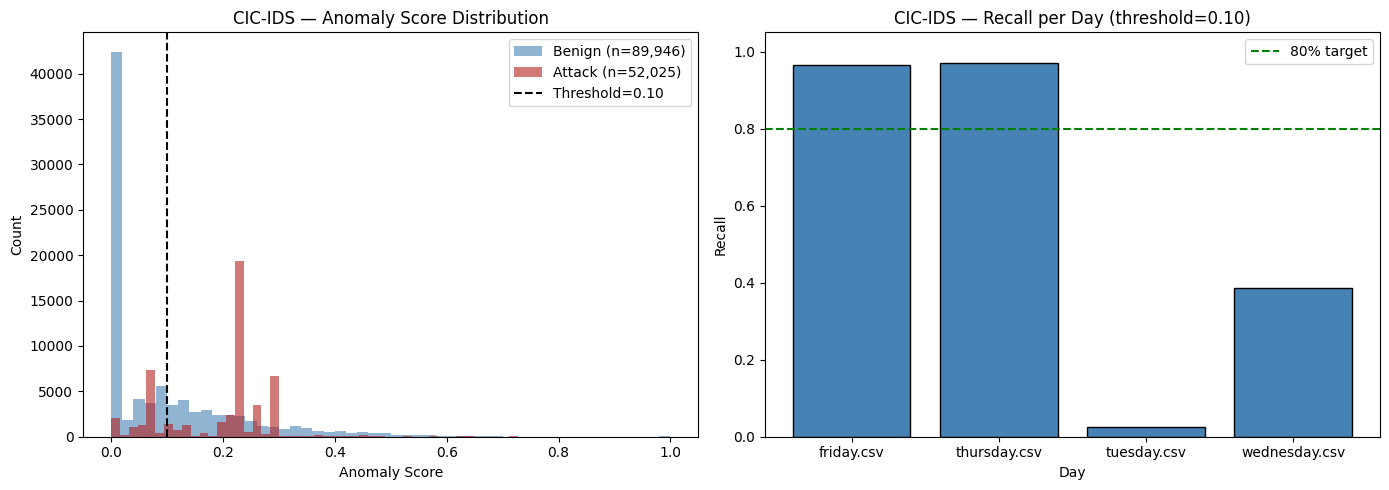

Chart 1 — CIC-IDS Network Layer
  Benign mean score : 0.0975
  Attack mean score : 0.1973
  Score gap         : +0.0998  (good separation)


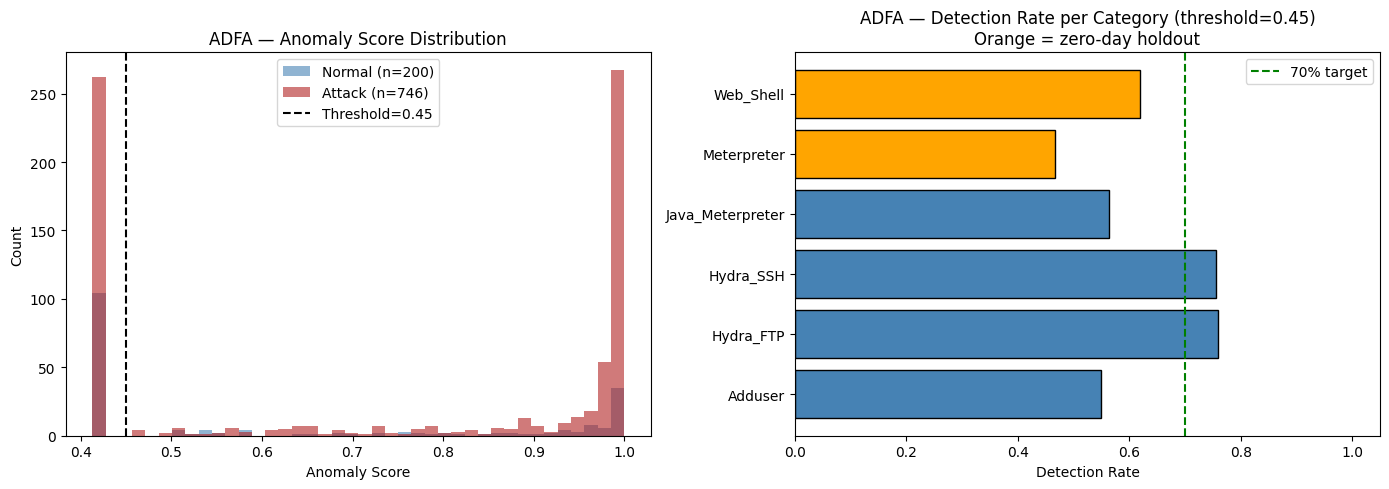


Chart 2 — ADFA Host Layer
  Normal mean score : 0.6288
  Attack mean score : 0.7434
  Score gap         : +0.1146


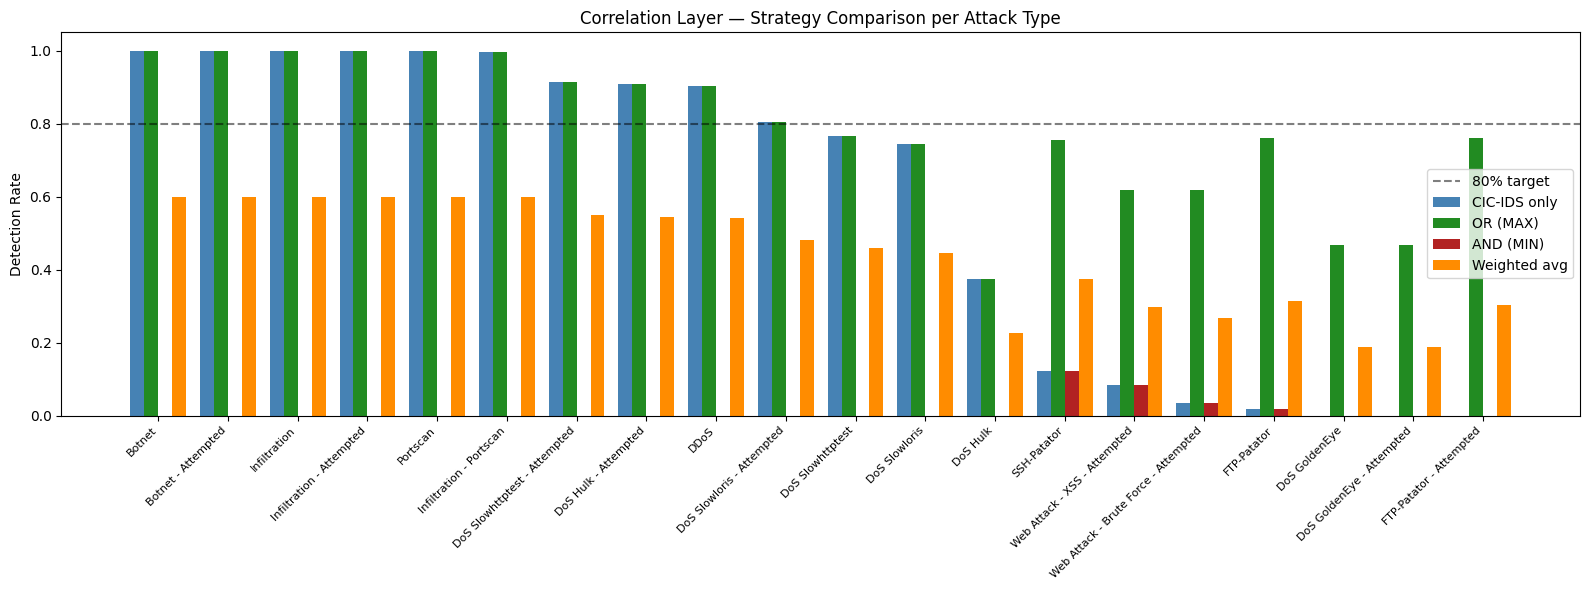


Chart 3 — Correlation Layer Strategy Comparison
  Attack types fully missed (< 20% detection):
    CIC-IDS alone : 7
    OR strategy   : 0  <- chosen strategy
    AND strategy  : 20
    Weighted avg  : 2


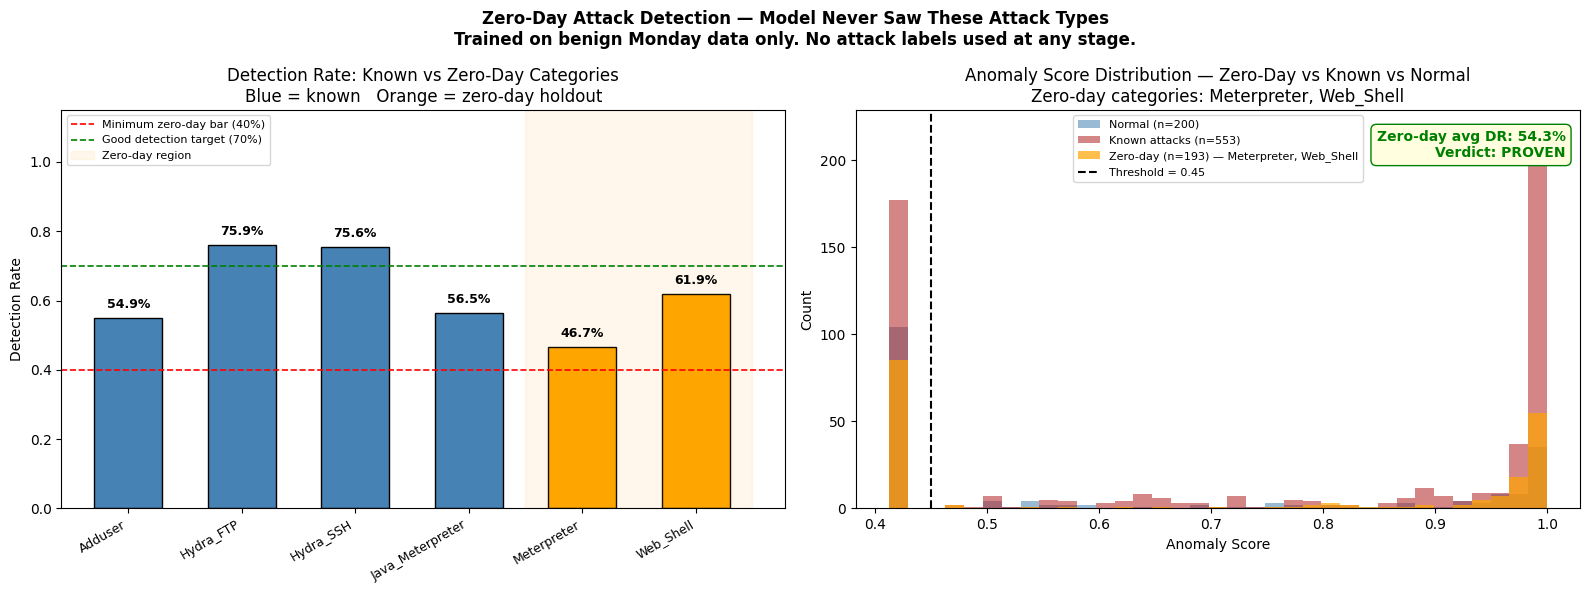


Chart 4 — Zero-Day Detection Summary
─────────────────────────────────────────────
  Holdout categories : Meterpreter, Web_Shell
  Never used during training or threshold tuning.

  DETECTED  Meterpreter             35/75 files  (46.7%)
  DETECTED  Web_Shell               73/118 files  (61.9%)

  Average zero-day DR : 54.3%
  Zero-day proven     : PROVEN


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
cic_csv = os.path.join(OUTPUT_DIR, "step6_anomaly_results.csv")
if os.path.exists(cic_csv):
    results_df = pd.read_csv(cic_csv)
    b = results_df[results_df['true_binary'] == 'NORMAL']['anomaly_score']
    a = results_df[results_df['true_binary'] == 'ATTACK']['anomaly_score']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(b, bins=50, alpha=0.6, color='steelblue', label=f'Benign (n={len(b):,})')
    axes[0].hist(a, bins=50, alpha=0.6, color='firebrick', label=f'Attack (n={len(a):,})')
    axes[0].axvline(0.10, color='black', linestyle='--', label='Threshold=0.10')
    axes[0].set_title('CIC-IDS — Anomaly Score Distribution')
    axes[0].set_xlabel('Anomaly Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    days = []
    for fname, grp in results_df.groupby('file'):
        pred     = grp['anomaly_score'] >= 0.10
        true_atk = grp['true_binary'] == 'ATTACK'
        TP = int(( pred &  true_atk).sum())
        FN = int((~pred &  true_atk).sum())
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        days.append({'day': fname, 'recall': recall})
    day_df = pd.DataFrame(days)
    axes[1].bar(day_df['day'], day_df['recall'], color='steelblue', edgecolor='black')
    axes[1].axhline(0.80, color='green', linestyle='--', label='80% target')
    axes[1].set_title('CIC-IDS — Recall per Day (threshold=0.10)')
    axes[1].set_xlabel('Day')
    axes[1].set_ylabel('Recall')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    print("Chart 1 — CIC-IDS Network Layer")
    print(f"  Benign mean score : {b.mean():.4f}")
    print(f"  Attack mean score : {a.mean():.4f}")
    print(f"  Score gap         : {a.mean()-b.mean():+.4f}  "
          f"({'good separation' if a.mean()-b.mean() > 0.05 else 'low separation'})")



adfa_pkl = os.path.join(OUTPUT_DIR, "adfa_step3_results.pkl")
if os.path.exists(adfa_pkl):
    with open(adfa_pkl, 'rb') as f:
        adfa_data = pickle.load(f)
    adfa_df = adfa_data['results_df']
    nrm = adfa_df[adfa_df['true_binary'] == 'NORMAL']['anomaly_score']
    atk = adfa_df[adfa_df['true_binary'] == 'ATTACK']['anomaly_score']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(nrm, bins=40, alpha=0.6, color='steelblue', label=f'Normal (n={len(nrm)})')
    axes[0].hist(atk, bins=40, alpha=0.6, color='firebrick', label=f'Attack (n={len(atk)})')
    axes[0].axvline(0.45, color='black', linestyle='--', label='Threshold=0.45')
    axes[0].set_title('ADFA — Anomaly Score Distribution')
    axes[0].set_xlabel('Anomaly Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    per_cat = adfa_data['per_category']
    cats    = [d['category'] for d in per_cat]
    rates   = [d['det_rate'] for d in per_cat]
    colors  = ['orange' if d['zero_day'] else 'steelblue' for d in per_cat]
    axes[1].barh(cats, rates, color=colors, edgecolor='black')
    axes[1].axvline(0.70, color='green', linestyle='--', label='70% target')
    axes[1].set_title('ADFA — Detection Rate per Category (threshold=0.45)\nOrange = zero-day holdout')
    axes[1].set_xlabel('Detection Rate')
    axes[1].set_xlim(0, 1.05)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    print("\nChart 2 — ADFA Host Layer")
    print(f"  Normal mean score : {nrm.mean():.4f}")
    print(f"  Attack mean score : {atk.mean():.4f}")
    print(f"  Score gap         : {atk.mean()-nrm.mean():+.4f}")



corr_csv = os.path.join(OUTPUT_DIR, "correlation_results.csv")
if os.path.exists(corr_csv):
    corr_df = pd.read_csv(corr_csv)
    x = np.arange(len(corr_df))
    w = 0.2

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - w*1.5, corr_df['cic_rate'],  w, label='CIC-IDS only', color='steelblue')
    ax.bar(x - w*0.5, corr_df['or_rate'],   w, label='OR (MAX)',     color='forestgreen')
    ax.bar(x + w*0.5, corr_df['and_rate'],  w, label='AND (MIN)',    color='firebrick')
    ax.bar(x + w*1.5, corr_df['wgt_rate'],  w, label='Weighted avg', color='darkorange')
    ax.axhline(0.80, color='black', linestyle='--', alpha=0.5, label='80% target')
    ax.set_xticks(x)
    ax.set_xticklabels(corr_df['attack_type'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Detection Rate')
    ax.set_title('Correlation Layer — Strategy Comparison per Attack Type')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("\nChart 3 — Correlation Layer Strategy Comparison")
    print(f"  Attack types fully missed (< 20% detection):")
    print(f"    CIC-IDS alone : {(corr_df['cic_rate'] < 0.20).sum()}")
    print(f"    OR strategy   : {(corr_df['or_rate']  < 0.20).sum()}  <- chosen strategy")
    print(f"    AND strategy  : {(corr_df['and_rate'] < 0.20).sum()}")
    print(f"    Weighted avg  : {(corr_df['wgt_rate'] < 0.20).sum()}")



if os.path.exists(adfa_pkl):
    with open(adfa_pkl, 'rb') as f:
        adfa_data = pickle.load(f)

    per_cat   = adfa_data['per_category']
    holdout   = adfa_data.get('holdout_cats', ['Meterpreter', 'Web_Shell'])
    threshold = adfa_data.get('threshold', 0.45)
    zd_avg_dr = adfa_data.get('zeroday_avg_dr', 0.0)
    zd_proven = adfa_data.get('zeroday_proven', False)

    known_cats = [d for d in per_cat if not d['zero_day']]
    zd_cats    = [d for d in per_cat if d['zero_day']]
    all_cats   = known_cats + zd_cats

    all_names  = [d['category'] for d in all_cats]
    all_rates  = [d['det_rate'] for d in all_cats]
    all_colors = ['steelblue' if not d['zero_day'] else 'orange' for d in all_cats]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        'Zero-Day Attack Detection — Model Never Saw These Attack Types\n'
        'Trained on benign Monday data only. No attack labels used at any stage.',
        fontsize=12, fontweight='bold'
    )

    # ── Left: Detection rate bar chart ───────────────────────────────────────
    x_pos = np.arange(len(all_names))
    bars  = axes[0].bar(x_pos, all_rates, color=all_colors, edgecolor='black', width=0.6)

    axes[0].axhline(0.40, color='red',   linestyle='--', linewidth=1.2,
                    label='Minimum zero-day bar (40%)')
    axes[0].axhline(0.70, color='green', linestyle='--', linewidth=1.2,
                    label='Good detection target (70%)')

    # Label each bar with its detection rate percentage
    for bar, rate in zip(bars, all_rates):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{rate*100:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    # Shade zero-day region in background
    if zd_cats:
        zd_start = len(known_cats) - 0.5
        axes[0].axvspan(zd_start, len(all_cats) - 0.5,
                        alpha=0.08, color='orange', label='Zero-day region')

    # Fix: use set_ticks before set_ticklabels to avoid UserWarning
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(all_names, rotation=30, ha='right', fontsize=9)
    axes[0].set_title('Detection Rate: Known vs Zero-Day Categories\n'
                      'Blue = known   Orange = zero-day holdout')
    axes[0].set_ylabel('Detection Rate')
    axes[0].set_ylim(0, 1.15)
    axes[0].legend(fontsize=8)

    # ── Right: Score distribution — Normal vs Known vs Zero-Day ──────────────
    adfa_df  = adfa_data['results_df']
    zd_names = [d['category'] for d in zd_cats]

    normal_scores = adfa_df[adfa_df['true_binary'] == 'NORMAL']['anomaly_score']
    zd_scores     = adfa_df[adfa_df['category'].isin(zd_names)]['anomaly_score']
    known_scores  = adfa_df[
        (adfa_df['true_binary'] == 'ATTACK') &
        (~adfa_df['category'].isin(zd_names))
    ]['anomaly_score']

    axes[1].hist(normal_scores, bins=35, alpha=0.55, color='steelblue',
                 label=f'Normal (n={len(normal_scores)})')
    axes[1].hist(known_scores,  bins=35, alpha=0.55, color='firebrick',
                 label=f'Known attacks (n={len(known_scores)})')
    axes[1].hist(zd_scores,     bins=35, alpha=0.70, color='orange',
                 label=f'Zero-day (n={len(zd_scores)}) — {", ".join(zd_names)}')
    axes[1].axvline(threshold, color='black', linestyle='--', linewidth=1.5,
                    label=f'Threshold = {threshold}')

    verdict = 'PROVEN' if zd_proven else 'NOT PROVEN'
    color   = 'green'  if zd_proven else 'red'
    axes[1].text(
        0.98, 0.95,
        f'Zero-day avg DR: {zd_avg_dr*100:.1f}%\nVerdict: {verdict}',
        transform=axes[1].transAxes,
        ha='right', va='top', fontsize=10, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor=color)
    )

    axes[1].set_title(
        'Anomaly Score Distribution — Zero-Day vs Known vs Normal\n'
        f'Zero-day categories: {", ".join(zd_names)}'
    )
    axes[1].set_xlabel('Anomaly Score')
    axes[1].set_ylabel('Count')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\nChart 4 — Zero-Day Detection Summary")
    print(f"{'─'*45}")
    print(f"  Holdout categories : {', '.join(holdout)}")
    print(f"  Never used during training or threshold tuning.")
    print()
    for d in zd_cats:
        status = 'DETECTED' if d['det_rate'] >= 0.40 else 'MISSED'
        print(f"  {status}  {d['category']:<22}"
              f"  {d['detected']}/{d['files']} files"
              f"  ({d['det_rate']*100:.1f}%)")
    print(f"\n  Average zero-day DR : {zd_avg_dr*100:.1f}%")
    print(f"  Zero-day proven     : {verdict}")

else:
    print("Run all steps first to generate output files.")